# Domain-Based Gene Family Analysis with InterProScan


Great! Welcome to the domain analysis jupyter notebook :)

This analysis aims to detect short conserved amino acid sequence motifs in domains of the light chain of immunoglobulins. And evaluates their association with gene family classification and antigen specificty.

This jupyter notebook is structured into three main parts: an **experimenting phase** where we tested and learned about InterProScan, a **focused light chain analysis** including the results used in the poster presentation, and an **outlook section**, discussing further opportunites and limitations of this approach.

The results of the poster were created in 2.6(d) and 2.7(c)

The analysis is supported by InterProScan and ChatGPT. 

InterProScan: https://github.com/ebi-pf-team/interproscan/releases  
ChatGPT: https://chatgpt.com/

## 1. Experimenting phase

This section is not relevant for the poster charts.

### 1.1 Installation of InterProScan

(a) Download latest verion from https://github.com/ebi-pf-team/interproscan/releases    

-> IMPORTANT: Unzip into a fitting folder, for example:
cd blasting  
cd domain_analysis  
cd interproscan-5.74-105.0  
tar -xzvf interproscan-5.74-105.0-64-bit.tar.gz


(b) Test if interproscan works; Requirements copy and run in terminal in the folder where interproscan-5.74-105.0 is located:
  
!./interproscan.sh -i test_all_appl.fasta -f tsv  

(c) OPTIONAL: Only once needed, this creates a target directory in the folder of interproscan-5.74-105.0:  
  
!mkdir -p ~/group04-team03/blasting/domain_analysis/interproscan-5.74-105.0/results

For the results for the focused analysis section.
!mkdir -p ~/group04-team03/blasting/domain_analysis/results

### 1.2 Start exploring

(a) First setting directories and running first InterProScan scan

group04-team03/blasting/inter_pro_scan/temp folder needs to be created before running the code for temporary data


In [ ]:
# Requirment is to have queryOmicron.fasta or any other small fasta to test (change input path accordingly)
# queryOmircon.fasta can be created with group04-team03/archive/mmseqs2_EVEscape /scripts/TODOblasting_with_ MMseqs2.ipynb 

input_omicron_fasta = "../data/queryOmicron.fasta" # Input for InterProScan anaylsis
output_file = "../results/ipr_test_1.tsv" # Output for tsv files
output_dir = "../results" # General output directory
interproscan_dir = "../interproscan-5.74-105.0" # Location of interproscan, to run without terminal


# Creating "../results/ipr_test_1.tsv" with interproscan: scanning protein sequence against a collection of protein signature databases
import subprocess

# cmd creates a list of arguments to run the command-line tool interproscan.sh
cmd = [
    f"{interproscan_dir}/interproscan.sh", # Run interproscan in the specific directory where it was installed
    "-i", input_omicron_fasta, # Input data; FASTA with protein sequences required
    "-f", "tsv", # Output format is a tsv file for analysis with pandas
    "-goterms", # also "Gene Ontology" - not needed for our analysis
    "-iprlookup", # adds additional InterPro-Information (Description)
     "--tempdir", "../temp", # Use the group04-team03/blasting/inter_pro_scan/temp folder for temporary files
    "-cpu", "12", # Using 12 CPU cores -> parallel -> faster scan
    "-o", output_file, # Where the output file should be stored
    "--applications", "Pfam,SMART,ProSiteProfiles" # Specifies the databanks to be analysed -> faster than all available
]

# Run the upper commant and showing the terminal output
result = subprocess.run(cmd, capture_output=True, text=True)

# Status
print("Return code:", result.returncode) # 0 -> succesful run
print("stdout:\n", result.stdout) # Hints to the scanning process
print("stderr:\n", result.stderr) # Shows error message

Return code: 0
stdout:
 05/07/2025 16:27:52:330 Welcome to InterProScan-5.74-105.0
05/07/2025 16:27:52:330 Running InterProScan v5 in STANDALONE mode... on Linux
05/07/2025 16:27:58:263 RunID: TomsBOOK2_20250705_162758111_ih68
05/07/2025 16:28:25:394 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/queryOmicron.fasta
05/07/2025 16:28:25:402 Running the following analyses:
[Pfam-37.3,ProSiteProfiles-2025_01,SMART-9.0]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-07-05 16:28:26,635 [Thread-6] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the same, you cannot use this match lookup ser

(b) Pandas anaylsis

In [34]:
# Import pandas for scan results (small fasta)
import pandas as pd

# Load tsv file without a header
df = pd.read_csv(output_file, sep="\t", header=None)

# Add fitting column names
df.columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]

df.head()


,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways
0,7CAB_1|Chains,510eb9f9b31257fc1b9117f0cfb6e5c2,1208,Pfam,PF16451,"Betacoronavirus-like spike glycoprotein S1, N-...",33,337,1.700000e-66,T,05-07-2025,IPR032500,"Spike glycoprotein S1, N-terminal domain, beta...",-,-
1,7CAB_1|Chains,510eb9f9b31257fc1b9117f0cfb6e5c2,1208,Pfam,PF09408,"Betacoronavirus spike glycoprotein S1, recepto...",349,526,1.100000e-37,T,05-07-2025,IPR018548,"Spike (S) protein S1 subunit, receptor-binding...",-,-
2,7CAB_1|Chains,510eb9f9b31257fc1b9117f0cfb6e5c2,1208,Pfam,PF01601,Coronavirus spike glycoprotein S2,711,1208,2.100000e-177,T,05-07-2025,IPR002552,"Spike glycoprotein S2, coronavirus",GO:0016020(InterPro)|GO:0019031(InterPro)|GO:0...,-
3,7CAB_1|Chains,510eb9f9b31257fc1b9117f0cfb6e5c2,1208,ProSiteProfiles,PS51922,Betacoronavirus spike (S) glycoprotein S1 subu...,9,303,4.926595e+01,T,05-07-2025,IPR032500,"Spike glycoprotein S1, N-terminal domain, beta...",-,-
4,7CAB_1|Chains,510eb9f9b31257fc1b9117f0cfb6e5c2,1208,ProSiteProfiles,PS51921,Betacoronavirus spike (S) glycoprotein S1 subu...,334,527,6.451016e+01,T,05-07-2025,IPR018548,"Spike (S) protein S1 subunit, receptor-binding...",-,-


In [35]:
# Counting domain data and checking output
# .str.extract(r"^(\w+)") extracts only first "Word" inlcuding letters, numbers and underlines (_)
df["Protein Accession Clean"] = df["Protein Accession"].str.extract(r"^(\w+)")

# groupby -> groups the same cleaned IDs
# size -> counts the rows per group = #domains per group
# reset_index creates a df with new column
domain_counts = df.groupby("Protein Accession Clean").size().reset_index(name="Domain Count")

domain_counts.head()


,Protein Accession Clean,Domain Count
0,6VXC_1,4
1,7BNN_1,9
2,7CAB_1,8


In [39]:
# Output path for domain counts
output_path = "../results/ipr_test_1_domain_counts_per_protein.tsv"

# Save
domain_counts.to_csv(output_path, sep="\t", index=False)

(c) Visualisation experiment

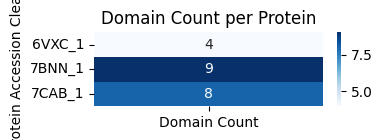

In [42]:
# Test heatmap with small sample size
import pandas as pd

df = pd.read_csv("../results/ipr_test_1_domain_counts_per_protein.tsv", sep="\t")
import seaborn as sns
import matplotlib.pyplot as plt

# For protein IDs on y-axis
df.set_index("Protein Accession Clean", inplace=True)

# Heatmap zeichnen
plt.figure(figsize=(4, max(1, 0.5 * len(df)))) # wight and dynamic hight
sns.heatmap(df, annot=True, cmap="Blues", cbar=True)
plt.title("Domain Count per Protein")
plt.tight_layout()
plt.show()


Conclusion (1.2): First test is succesful! For each PDB accession the number of structural or functional domains was identified.

### 1.3 Creating subset of 10, 100 and all sequences and accelerate interproscan processing

In [1]:
# Testing with our own cleaned data
# Create subset with 10 sequences
from Bio import SeqIO

input_fasta = "../data/lchain_sequences_deduplicated.fasta"
output_subset = "../data/lchain_subset_10.fasta"

# Number of taken sequences
subset_size = 10

records = list(SeqIO.parse(input_fasta, "fasta"))
subset = records[:subset_size]  # takes the first 10

with open(output_subset, "w") as out_f:
    SeqIO.write(subset, out_f, "fasta")


In [11]:
# Create subset with 100 sequences
from Bio import SeqIO

input_fasta = "../data/lchain_sequences_deduplicated.fasta"
output_subset = "../data/lchain_subset_100.fasta"

# Anzahl der gewünschten Sequenzen
subset_size = 100

records = list(SeqIO.parse(input_fasta, "fasta"))
subset = records[:subset_size]  # takes the first 10

with open(output_subset, "w") as out_f:
    SeqIO.write(subset, out_f, "fasta")


In [10]:
# Input files
input_lchain_fasta ="../data/lchain_subset_10.fasta"
input_lchain_fasta100 ="../data/lchain_subset_100.fasta"
input_lchain_fastatotal = "../data/lchain_sequences_deduplicated.fasta"

# Output files
output_file = "../results/interproscan_lchain_subset_10.tsv"
output_file100 = "../results/interproscan_lchain_subset_100.tsv"
output_filetotal = "../results/interproscan_lchain_total.tsv"

# Directories 
output_dir = "../results"
interproscan_dir = "../interproscan-5.74-105.0"

In [13]:
# SLOW PROCESSING: NOT IN USE
# Creating tsv with interproscan: scanning protein sequence against a collection of protein signature databases
import subprocess

cmd = [
    f"{interproscan_dir}/interproscan.sh", # Run interproscan in the specific directory where it was installed
    "-i", input_lchain_fasta , # Input data
    "-f", "tsv", # creating a tsv file
    "-goterms",
    "-iprlookup",
     "--tempdir", "../temp", # Use the group04-team03/blasting/inter_pro_scan/temp folder for temporary files
    "-cpu", "14",
    "-o", output_file # Output file
]

# Run the upper commant 
result = subprocess.run(cmd, capture_output=True, text=True)

# Status
print("Return code:", result.returncode)
print("stdout:\n", result.stdout)
print("stderr:\n", result.stderr)

KeyboardInterrupt: 

In [ ]:
# FASTER Only Pfam and more cpu cores used
# Standard: InterProScan all 15 data banks 
# For high speed only analyse Pfam data base 
# TODO integrate also Pfam, SMART, ProSiteProfiles -> for domain identification enought

# AND 


import os
import subprocess
import multiprocessing

# Automatisch Anzahl der verfügbaren CPUs ermitteln
cpu_count = max(1, multiprocessing.cpu_count() - 2)

# Debug-Ausgabe (optional)
print(f"Nutze {cpu_count} CPUs für InterProScan")

# InterProScan-Aufruf konfigurieren
cmd = [
    f"{interproscan_dir}/interproscan.sh",
    "-i", input_lchain_fasta,
    "-f", "tsv",
    "-goterms",
    "-iprlookup",
    "--applications", "Pfam",          # only Pfam for speed
    "--tempdir", "../temp",
    "-cpu", str(cpu_count),
    "-o", output_file
]

# Ausführen
result = subprocess.run(cmd, capture_output=True, text=True)

# Status ausgeben
print("Return code:", result.returncode)
print("stdout:\n", result.stdout)
print("stderr:\n", result.stderr)


Nutze 14 CPUs für InterProScan
Return code: 0
stdout:
 30/06/2025 15:27:02:457 Welcome to InterProScan-5.74-105.0
30/06/2025 15:27:02:458 Running InterProScan v5 in STANDALONE mode... on Linux
30/06/2025 15:27:08:671 RunID: TomsBOOK2_20250630_152708547_l0rr
30/06/2025 15:27:18:137 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_subset_10.fasta
30/06/2025 15:27:18:137 Running the following analyses:
[Pfam-37.3]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-06-30 15:27:19,183 [Thread-6] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the same, you cannot use this match lookup se

In [ ]:
# First look at result of subset 10 fasta scan via pandas
import pandas as pd

output_file = "../results/interproscan_lchain_subset_10.tsv"

# Datei einlesen
df = pd.read_csv(output_file, sep="\t", header=None)

# Add fitting column names
df.columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]

df.head()

,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways
0,7ZOZ_entity3_chainL,7b843020dfe3d0be6728cafced9c965c,214,Pfam,PF07686,Immunoglobulin V-set domain,6,106,6.600000e-15,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-
1,7ZOZ_entity3_chainL,7b843020dfe3d0be6728cafced9c965c,214,Pfam,PF07654,Immunoglobulin C1-set domain,115,201,6.600000e-21,T,30-06-2025,IPR003597,Immunoglobulin C1-set,-,-
2,"4KXZ_entity3_chainI,L,M,P",8d69266d34d52ddd43dddf89dd13fd48,215,Pfam,PF07686,Immunoglobulin V-set domain,6,107,7.600000e-16,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-
3,"4KXZ_entity3_chainI,L,M,P",8d69266d34d52ddd43dddf89dd13fd48,215,Pfam,PF07654,Immunoglobulin C1-set domain,116,202,6.600000e-21,T,30-06-2025,IPR003597,Immunoglobulin C1-set,-,-
4,8IVX_entity3_chainL,ddfd44253613ec1d6358539013c6dd46,215,Pfam,PF07686,Immunoglobulin V-set domain,8,107,2.000000e-13,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-


In [ ]:
# Counting domain data and checking output 
df["Protein Accession Clean"] = df["Protein Accession"].str.extract(r"^(\w+)")
domain_counts = df.groupby("Protein Accession Clean").size().reset_index(name="Domain Count")

domain_counts.head()

,Protein Accession Clean,Domain Count
0,4KXZ_entity3_chainI,2
1,5GGT_entity3_chainL,2
2,6MHR_entity2_chainB,2
3,6PE8_entity2_chainB,2
4,6VMK_entity1_chainC,1


In [ ]:
domain_counts.tail()

,Protein Accession Clean,Domain Count
5,6VMK_entity2_chainA,2
6,6VMK_entity3_chainB,2
7,7ZOZ_entity3_chainL,2
8,8IVW_entity3_chainC,2
9,8IVX_entity3_chainL,2


### STEP 4 Function for faster analysis (**Relevant** function for final results; Subset testing is not)

In [51]:
# (Relevant function) Function for FAST InterProScan
import os
import subprocess
import multiprocessing

def run_interproscan_fast(interproscan_dir, input_fasta_path, output_path, temp_dir="../temp", applications="Pfam", extra_args=None):
    """
    Führt InterProScan mit konfigurierter Anwendung aus.

    Args:
        interproscan_dir (str): Pfad zum InterProScan-Installationsverzeichnis.
        input_fasta_path (str): Pfad zur Eingabe-FASTA-Datei.
        output_path (str): Zielpfad für die TSV-Ausgabe.
        temp_dir (str): Verzeichnis für temporäre Dateien (Default: "../temp").
        applications (str): Datenbanken für Analyse, z.B. "Pfam" oder "Pfam,SMART,ProSiteProfiles".
        extra_args (list): Zusätzliche Argumente als Liste (optional).

    Returns:
        result (subprocess.CompletedProcess): Ergebnisobjekt von subprocess.run
    """
    cpu_count = max(1, multiprocessing.cpu_count() - 2)
    print(f"Nutze {cpu_count} CPUs für InterProScan")

    cmd = [
        os.path.join(interproscan_dir, "interproscan.sh"),
        "-i", input_fasta_path,
        "-f", "tsv",
        "-goterms",
        "-iprlookup",
        "--applications", applications,
        "--tempdir", temp_dir,
        "-cpu", str(cpu_count),
        "-o", output_path
    ]

    if extra_args:
        cmd.extend(extra_args)

    result = subprocess.run(cmd, capture_output=True, text=True)

    print("Return code:", result.returncode)
    print("stdout:\n", result.stdout)
    print("stderr:\n", result.stderr)

    return result

In [ ]:
# RUNNING 100 -> 100 sequences creating a interproscan file
run_interproscan_fast(
    interproscan_dir= "../interproscan-5.74-105.0",
    input_fasta_path= "../data/lchain_subset_100.fasta",
    output_path = output_file100,
    applications="Pfam" 
)

Nutze 14 CPUs für InterProScan
Return code: 0
stdout:
 01/07/2025 13:49:38:664 Welcome to InterProScan-5.74-105.0
01/07/2025 13:49:38:664 Running InterProScan v5 in STANDALONE mode... on Linux
01/07/2025 13:49:43:943 RunID: TomsBOOK2_20250701_134943807_3dyi
01/07/2025 13:49:52:325 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_subset_100.fasta
01/07/2025 13:49:52:326 Running the following analyses:
[Pfam-37.3]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-07-01 13:49:53,385 [Thread-6] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the same, you cannot use this match lookup s

CompletedProcess(args=['../interproscan-5.74-105.0/interproscan.sh', '-i', '../data/lchain_subset_100.fasta', '-f', 'tsv', '-goterms', '-iprlookup', '--applications', 'Pfam', '--tempdir', '../temp', '-cpu', '14', '-o', '../results/interproscan_lchain_subset_100.tsv'], returncode=0, stdout='01/07/2025 13:49:38:664 Welcome to InterProScan-5.74-105.0\n01/07/2025 13:49:38:664 Running InterProScan v5 in STANDALONE mode... on Linux\n01/07/2025 13:49:43:943 RunID: TomsBOOK2_20250701_134943807_3dyi\n01/07/2025 13:49:52:325 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_subset_100.fasta\n01/07/2025 13:49:52:326 Running the following analyses:\n[Pfam-37.3]\nAvailable matches will be retrieved from the pre-calculated match lookup service.\n\nMatches for any sequences that are not represented in the lookup service will be calculated locally.\n2025-07-01 13:49:53,385 [Thread-6] [uk.ac.ebi.interpro.scan.business.sequence.Ber

In [ ]:
import pandas as pd

input_file_ipr100 = "../results/interproscan_lchain_subset_100.tsv"
df_ipr100 = pd.read_csv(input_file_ipr100, sep="\t", header=1)
df_ipr100.columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]

input_file_genfamilies = "../data/light_subclass.csv"
df_genfamilies100 = pd.read_csv(input_file_genfamilies, sep=",", header=0) # header=0 important for column names


In [ ]:
# RUNNING total -> all sequences
run_interproscan(
    interproscan_dir= "../interproscan-5.74-105.0",
    input_fasta_path = input_lchain_fastatotal,
    output_path= output_filetotal,
    applications="Pfam" 
)

Nutze 14 CPUs für InterProScan
Return code: 0
stdout:
 30/06/2025 16:14:23:126 Welcome to InterProScan-5.74-105.0
30/06/2025 16:14:23:126 Running InterProScan v5 in STANDALONE mode... on Linux
30/06/2025 16:14:29:497 RunID: TomsBOOK2_20250630_161429358_4f5x
30/06/2025 16:14:38:828 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_sequences_deduplicated.fasta
30/06/2025 16:14:38:829 Running the following analyses:
[Pfam-37.3]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-06-30 16:14:40,473 [Thread-12] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the same, you cannot use this m

CompletedProcess(args=['../interproscan-5.74-105.0/interproscan.sh', '-i', '../data/lchain_sequences_deduplicated.fasta', '-f', 'tsv', '-goterms', '-iprlookup', '--applications', 'Pfam', '--tempdir', '../temp', '-cpu', '14', '-o', '../results/interproscan_lchain_total.tsv'], returncode=0, stdout='30/06/2025 16:14:23:126 Welcome to InterProScan-5.74-105.0\n30/06/2025 16:14:23:126 Running InterProScan v5 in STANDALONE mode... on Linux\n30/06/2025 16:14:29:497 RunID: TomsBOOK2_20250630_161429358_4f5x\n30/06/2025 16:14:38:828 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_sequences_deduplicated.fasta\n30/06/2025 16:14:38:829 Running the following analyses:\n[Pfam-37.3]\nAvailable matches will be retrieved from the pre-calculated match lookup service.\n\nMatches for any sequences that are not represented in the lookup service will be calculated locally.\n2025-06-30 16:14:40,473 [Thread-12] [uk.ac.ebi.interpro.scan.b

In [ ]:
# MERGING total
import pandas as pd
input_file_total = "../results/interproscan_lchain_total.tsv"
df_ipr_total = pd.read_csv(input_file_total, sep="\t", header=0) 

df_ipr_total.columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]
input_file_genfamilies = "../data/light_subclass.csv"
df_genfamilies = pd.read_csv(input_file_genfamilies, sep=",", header=0) # header=0 important for column names


df_genfamilies["pdb_id"] = df_genfamilies["pdb"].str.extract(r"(\w{4})")[0].str.lower()
df_ipr_total["pdb_id"] = df_ipr_total["Protein Accession"].str.extract(r"(\w{4})")[0].str.lower()
merged_total = pd.merge(df_ipr_total, df_genfamilies, on="pdb_id", how="left")

import os

os.makedirs("../results", exist_ok=True)
merged_total.to_csv("../results/merged_total_ipr_genfamilies.csv", index=False)

merged_total.head()

,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways,pdb_id,pdb,antigen_species,light_subclass
0,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,Pfam,PF07686,Immunoglobulin V-set domain,5,108,4.100000e-15,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,6mi2,6mi2,homo sapiens,IGLV3
1,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,Pfam,PF07686,Immunoglobulin V-set domain,5,108,4.100000e-15,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,6mi2,6mi2,homo sapiens,IGLV3
2,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1
3,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1
4,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,30-06-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1


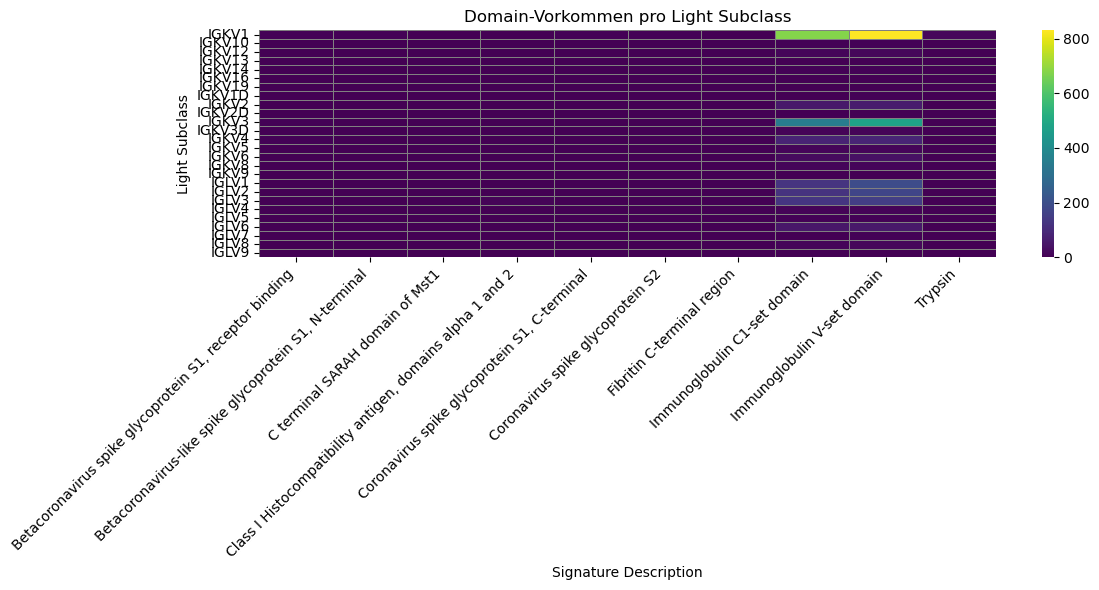

In [ ]:
### Creating heatmap for total
import seaborn as sns
import matplotlib.pyplot as plt

# Tabelle: wie oft kommt jede Domain-Beschreibung pro light_subclass vor?
heatmap_data = (
    merged_total.groupby(["light_subclass", "Signature Description"])
    .size()
    .unstack(fill_value=0)
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="viridis", linewidths=0.5, linecolor="gray")
plt.title("Domain-Vorkommen pro Light Subclass")
plt.xlabel("Signature Description")
plt.ylabel("Light Subclass")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [55]:
# RUNNING total fasta (-> all sequences) with Pfam, SMART and ProSiteProfiles
output_filetotal_Pfam_SMART_ProSiteProfiles = "../results/interproscan_lchain_total_Pfam_SMART_ProSiteProfiles.tsv"

run_interproscan(
    interproscan_dir= "../interproscan-5.74-105.0",
    input_fasta_path = input_lchain_fastatotal,
    output_path= output_filetotal_Pfam_SMART_ProSiteProfiles,
    applications="Pfam,SMART,ProSiteProfiles" 
)

Nutze 14 CPUs für InterProScan


KeyboardInterrupt: 

In [64]:
# MERGING total with all applications
import pandas as pd
input_file_total_Pfam_SMART_ProSiteProfiles  = "../results/interproscan_lchain_total_Pfam_SMART_ProSiteProfiles.tsv"
df_ipr_total_Pfam_SMART_ProSiteProfiles = pd.read_csv(input_file_total_Pfam_SMART_ProSiteProfiles , sep="\t", header=0) 

df_ipr_total_Pfam_SMART_ProSiteProfiles .columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]
input_file_genfamilies = "../data/light_subclass.csv"
df_genfamilies = pd.read_csv(input_file_genfamilies, sep=",", header=0) # header=0 important for column names


df_genfamilies["pdb_id"] = df_genfamilies["pdb"].str.extract(r"(\w{4})")[0].str.lower()
df_ipr_total_Pfam_SMART_ProSiteProfiles ["pdb_id"] = df_ipr_total_Pfam_SMART_ProSiteProfiles ["Protein Accession"].str.extract(r"(\w{4})")[0].str.lower()
merged_total_Pfam_SMART_ProSiteProfiles  = pd.merge(df_ipr_total_Pfam_SMART_ProSiteProfiles , df_genfamilies, on="pdb_id", how="left")

import os

os.makedirs("../results", exist_ok=True)
merged_total_Pfam_SMART_ProSiteProfiles .to_csv("../results/merged_total_ipr_genfamilies.csv", index=False)

merged_total_Pfam_SMART_ProSiteProfiles.head()

,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways,pdb_id,pdb,antigen_species,light_subclass
0,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,SMART,SM00409,IG_3c,7,108,6.700000e-13,T,30-06-2025,IPR003599,Immunoglobulin domain subtype,-,-,6mi2,6mi2,homo sapiens,IGLV3
1,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,SMART,SM00409,IG_3c,7,108,6.700000e-13,T,30-06-2025,IPR003599,Immunoglobulin domain subtype,-,-,6mi2,6mi2,homo sapiens,IGLV3
2,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,SMART,SM00409,IG_3c,121,209,4.800000e+01,T,30-06-2025,IPR003599,Immunoglobulin domain subtype,-,-,6mi2,6mi2,homo sapiens,IGLV3
3,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,SMART,SM00409,IG_3c,121,209,4.800000e+01,T,30-06-2025,IPR003599,Immunoglobulin domain subtype,-,-,6mi2,6mi2,homo sapiens,IGLV3
4,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,SMART,SM00407,igc1_4,131,205,5.700000e-30,T,30-06-2025,IPR003597,Immunoglobulin C1-set,-,-,6mi2,6mi2,homo sapiens,IGLV3


In [56]:
# 
import seaborn as sns
import matplotlib.pyplot as plt
import re

def plot_domain_heatmap600x0(
    df,
     value_col="Signature Description",
    class_col="light_subclass",
    min_total_count=600,
    cell_size=1.0,
    dpi=300,
    save_path=None
):
    """
    Plot heatmap with square, enlarged cells and high resolution, with numerically sorted subclasses.

    Parameters:
    - df: DataFrame
    - value_col: Domain column
    - class_col: Subclass column
    - min_total_count: Minimal domain count across all subclasses
    - cell_size: Cell size in inches
    - dpi: Plot resolution
    - save_path: Optional path to save image
    """
    # Aggregieren
    heatmap_data = (
        df.groupby([class_col, value_col])
        .size()
        .unstack(fill_value=0)
    )

    # Filter
    domain_totals = heatmap_data.sum(axis=0)
    filtered = heatmap_data.loc[:, domain_totals[domain_totals >= min_total_count].index]

    # Umbenennen "Immunoglobulin" zu "Ig"
    filtered.columns = filtered.columns.str.replace("Immunoglobulin", "Ig", regex=False)

    # Sortierung nach Nummer extrahiert aus light_subclass
    def subclass_sort_key(name):
        match = re.search(r"(\d+)", name)
        return (name[:4], int(match.group(1)) if match else 999)

    filtered = filtered.sort_index(key=lambda x: x.map(subclass_sort_key))

    # Größen berechnen
    n_rows, n_cols = filtered.shape
    fig_width = max(8, n_cols * cell_size)
    fig_height = max(6, n_rows * cell_size)

    # Plot
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    sns.heatmap(
        filtered,
        cmap="Blues",
        linewidths=0.2,
        linecolor="gray",
        square=True,
        cbar_kws={"shrink": 0.5},
        ax=ax
    )

    ax.set_title("domains in light subclass", fontsize=16)
    ax.set_xlabel("Signature Description", fontsize=12)
    ax.set_ylabel("light subclass", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()


In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import re

def plot_domain_heatmap600x600(
    df,
    value_col="Signature Description",
    class_col="light_subclass",
    min_total_count=600,
    cell_size=1.0,
    dpi=300,
    save_path=None
):
    """
    Plot heatmap of domain frequencies per light subclass with filters for:
    - minimum total domain count across subclasses
    - minimum total domain count per subclass
    """
    # Gruppierung
    heatmap_data = (
        df.groupby([class_col, value_col])
        .size()
        .unstack(fill_value=0)
    )

    # Spalten (Domains) filtern
    domain_totals = heatmap_data.sum(axis=0).astype(int)
    domain_mask = domain_totals > min_total_count
    heatmap_data = heatmap_data.loc[:, domain_mask]

    # Zeilen (Subklassen) filtern
    subclass_totals = heatmap_data.sum(axis=1).astype(int)
    subclass_mask = subclass_totals > min_total_count
    heatmap_data = heatmap_data.loc[subclass_mask, :]

    # Umbenennung: Immunoglobulin → Ig
    heatmap_data.columns = heatmap_data.columns.str.replace("Immunoglobulin", "Ig", regex=False)

    # Subklassen sortieren numerisch
    def subclass_sort_key(name):
        match = re.search(r"(\d+)", name)
        return (name[:4], int(match.group(1)) if match else 999)

    heatmap_data = heatmap_data.sort_index(key=lambda x: x.map(subclass_sort_key))

    # Größe berechnen
    n_rows, n_cols = heatmap_data.shape
    fig_width = max(8, n_cols * cell_size)
    fig_height = max(6, n_rows * cell_size)

    # Plot erstellen
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.2,
        linecolor="gray",
        square=True,
        cbar_kws={"shrink": 0.5},
        ax=ax
    )

    ax.set_title("Domains in Light Subclass", fontsize=16)
    ax.set_xlabel("Signature Description [>600 counts]", fontsize=12)
    ax.set_ylabel("Light Subclass [>600 counts]", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()


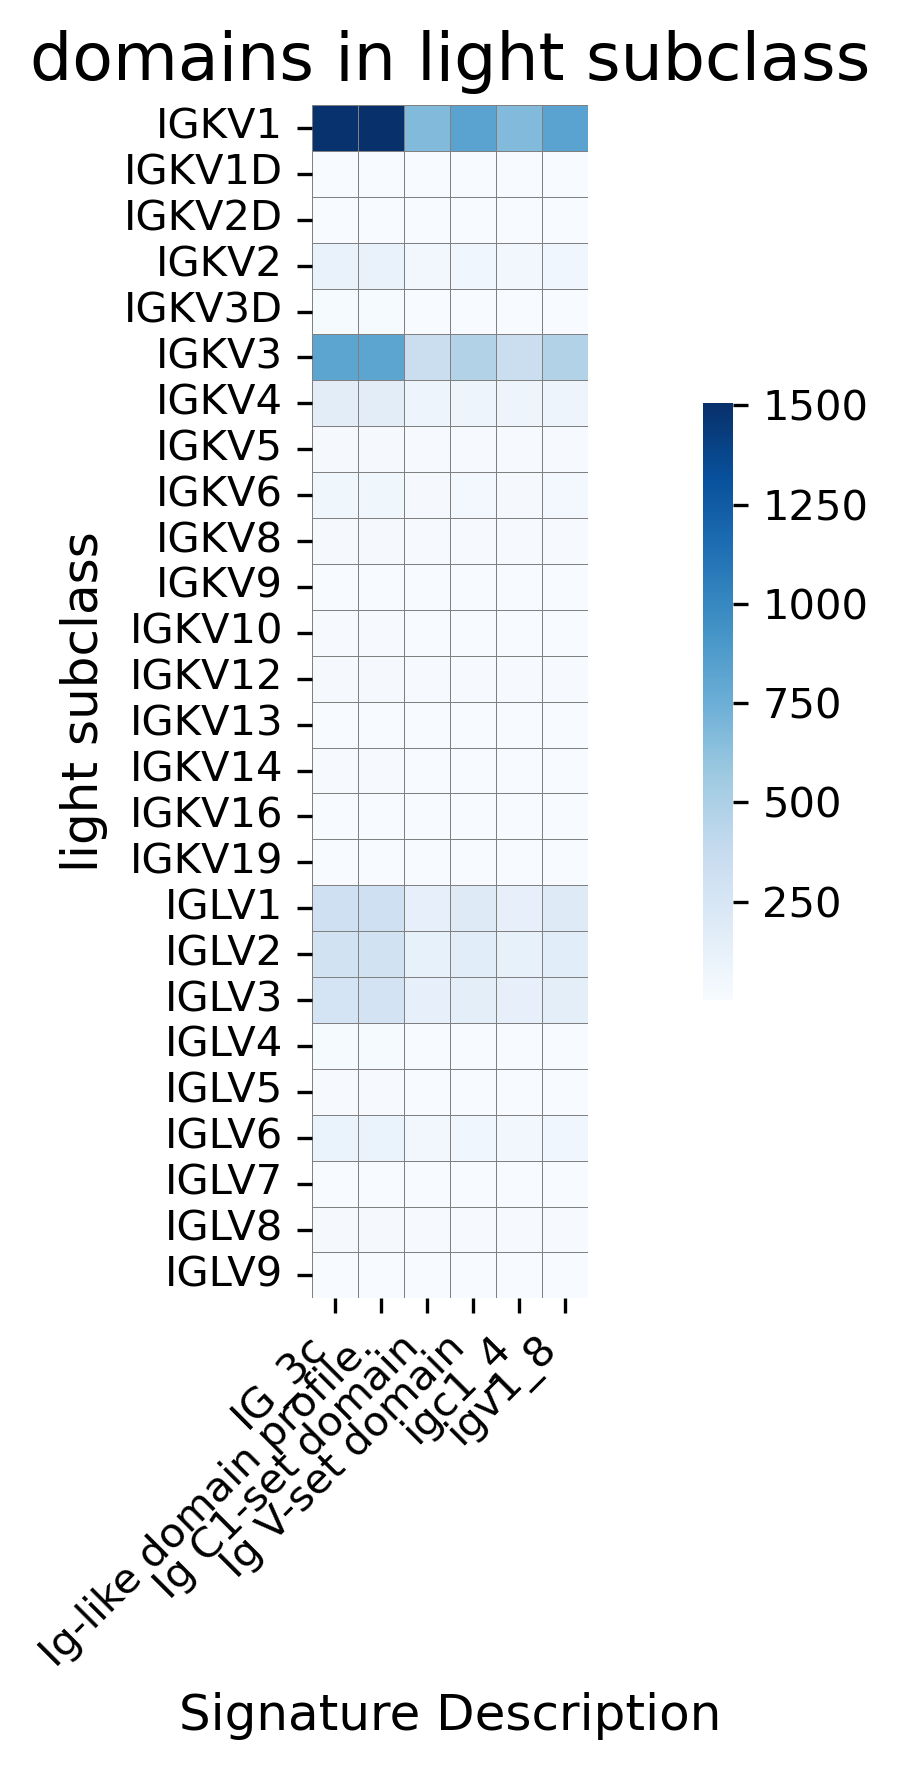

In [58]:
plot_domain_heatmap600x0(
    merged_total_Pfam_SMART_ProSiteProfiles,
    min_total_count=600,
    cell_size=0.1,
    dpi=300,
    save_path="../results/heatmap_sorted.png"
)


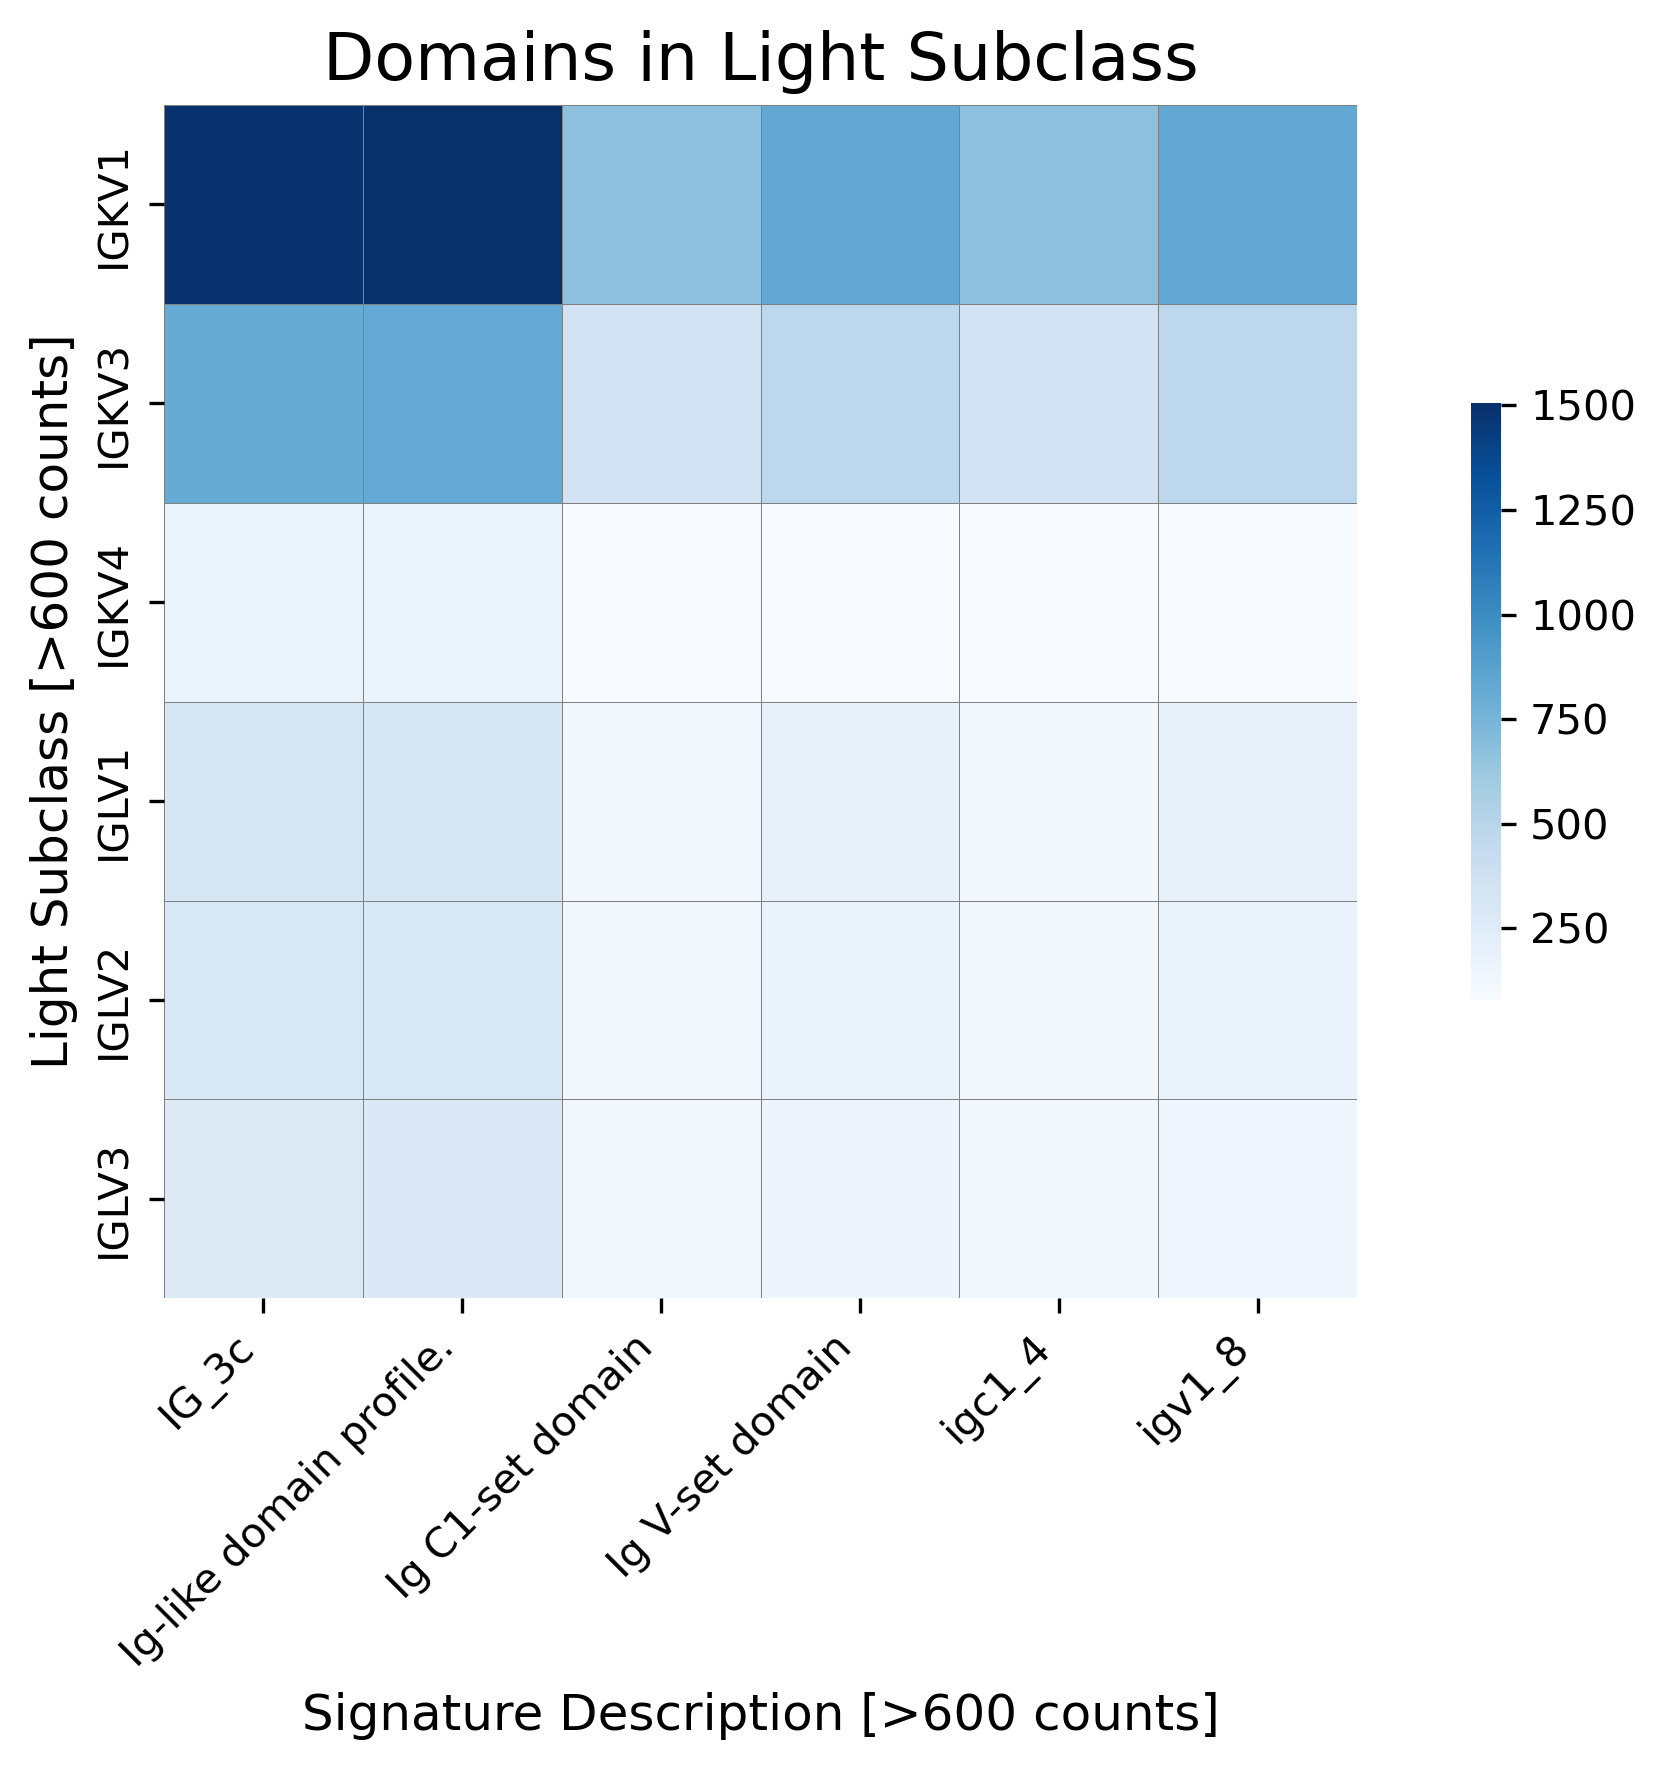

In [63]:
plot_domain_heatmap600x600(
    merged_total_Pfam_SMART_ProSiteProfiles,
    min_total_count=600,
    cell_size=0.1,
    dpi=300,
    save_path="../results/heatmap_sorted.png"
)

In [ ]:
# RUNNING total with all applications-> all sequences and all data bases
output_filetotal_all_applications = "../results/interproscan_lchain_total_all_applications.tsv"

run_interproscan(
    interproscan_dir= "../interproscan-5.74-105.0",
    input_fasta_path = input_lchain_fastatotal,
    output_path= output_filetotal_all_applications,
)

Nutze 14 CPUs für InterProScan
Return code: 0
stdout:
 01/07/2025 13:51:46:076 Welcome to InterProScan-5.74-105.0
01/07/2025 13:51:46:078 Running InterProScan v5 in STANDALONE mode... on Linux
01/07/2025 13:51:53:369 RunID: TomsBOOK2_20250701_135153201_doat
01/07/2025 13:52:08:260 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_sequences_deduplicated.fasta
01/07/2025 13:52:08:262 Running the following analyses:
[Pfam-37.3]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-07-01 13:52:10,274 [Thread-14] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the same, you cannot use this m

CompletedProcess(args=['../interproscan-5.74-105.0/interproscan.sh', '-i', '../data/lchain_sequences_deduplicated.fasta', '-f', 'tsv', '-goterms', '-iprlookup', '--applications', 'Pfam', '--tempdir', '../temp', '-cpu', '14', '-o', '../results/interproscan_lchain_total_all_applications.tsv'], returncode=0, stdout='01/07/2025 13:51:46:076 Welcome to InterProScan-5.74-105.0\n01/07/2025 13:51:46:078 Running InterProScan v5 in STANDALONE mode... on Linux\n01/07/2025 13:51:53:369 RunID: TomsBOOK2_20250701_135153201_doat\n01/07/2025 13:52:08:260 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../data/lchain_sequences_deduplicated.fasta\n01/07/2025 13:52:08:262 Running the following analyses:\n[Pfam-37.3]\nAvailable matches will be retrieved from the pre-calculated match lookup service.\n\nMatches for any sequences that are not represented in the lookup service will be calculated locally.\n2025-07-01 13:52:10,274 [Thread-14] [uk.ac.eb

In [65]:
# MERGING total
import pandas as pd
input_file_total_all_applications = "../results/interproscan_lchain_total_all_applications.tsv"
df_ipr_total_all_applications = pd.read_csv(input_file_total_all_applications, sep="\t", header=0) 

df_ipr_total_all_applications.columns = [
    "Protein Accession",        # z. B. 7CAB_1
    "Sequence MD5",             # z. B. 510eb9f9...
    "Sequence Length",          # z. B. 1208
    "Analysis",                 # z. B. Pfam, Gene3D, etc.
    "Signature Accession",      # z. B. PF16451
    "Signature Description",    # z. B. Betacoronavirus spike...
    "Start",                    # Start position
    "End",                      # End position
    "Score",                    # z. B. E-value, 0.0, etc.
    "Status",                   # T (true hit)
    "Date",                     # Date of running the scan
    "InterPro Accession",       # z. B. IPR032500
    "InterPro Description",     # z. B. Spike glycoprotein S1...
    "GO Terms",                  # not relevent
    "Pathways"                    # not relevent 
]
input_file_genfamilies = "../data/light_subclass.csv"
df_genfamilies = pd.read_csv(input_file_genfamilies, sep=",", header=0) # header=0 important for column names


df_genfamilies["pdb_id"] = df_genfamilies["pdb"].str.extract(r"(\w{4})")[0].str.lower()
df_ipr_total_all_applications["pdb_id"] = df_ipr_total_all_applications["Protein Accession"].str.extract(r"(\w{4})")[0].str.lower()
merged_total_all_applications = pd.merge(df_ipr_total_all_applications, df_genfamilies, on="pdb_id", how="left")

import os

os.makedirs("../results", exist_ok=True)
merged_total_all_applications.to_csv("../results/merged_total_ipr_genfamilies.csv", index=False)

merged_total_all_applications.head()

,Protein Accession,Sequence MD5,Sequence Length,Analysis,Signature Accession,Signature Description,Start,End,Score,Status,Date,InterPro Accession,InterPro Description,GO Terms,Pathways,pdb_id,pdb,antigen_species,light_subclass
0,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,Pfam,PF07686,Immunoglobulin V-set domain,5,108,4.100000e-15,T,01-07-2025,IPR013106,Immunoglobulin V-set domain,-,-,6mi2,6mi2,homo sapiens,IGLV3
1,"6MI2_entity2_chainB,E",7462d08ddfb9199a61ea770a6a2864be,214,Pfam,PF07686,Immunoglobulin V-set domain,5,108,4.100000e-15,T,01-07-2025,IPR013106,Immunoglobulin V-set domain,-,-,6mi2,6mi2,homo sapiens,IGLV3
2,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,01-07-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1
3,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,01-07-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1
4,"7XDL_entity4_chainJ,L,O",23af125c39a4863b86b93db10e6cf803,105,Pfam,PF07686,Immunoglobulin V-set domain,6,104,2.300000e-16,T,01-07-2025,IPR013106,Immunoglobulin V-set domain,-,-,7xdl,7xdl,severe acute respiratory syndrome coronavirus2,IGKV1


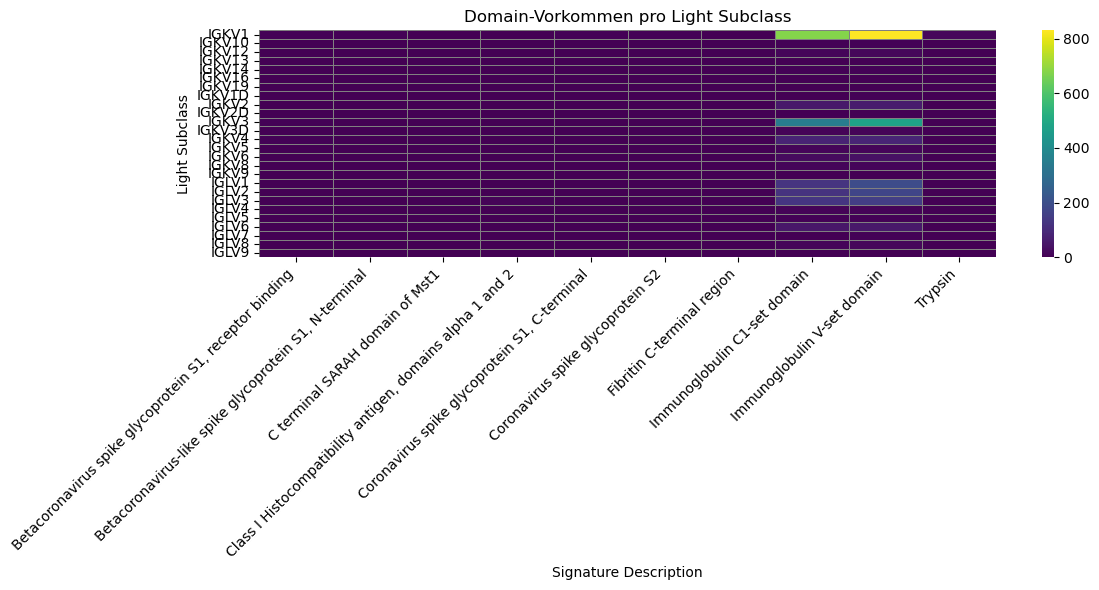

In [24]:
### Creating heatmap for total
import seaborn as sns
import matplotlib.pyplot as plt

# Tabelle: wie oft kommt jede Domain-Beschreibung pro light_subclass vor?
heatmap_data = (
    merged_total_all_applications.groupby(["light_subclass", "Signature Description"])
    .size()
    .unstack(fill_value=0)
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="viridis", linewidths=0.5, linecolor="gray")
plt.title("Domain-Vorkommen pro Light Subclass")
plt.xlabel("Signature Description")
plt.ylabel("Light Subclass")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### STEP 5 Tested antigen species (Not relevant for final results)

In [76]:
merged_total_Pfam_SMART_ProSiteProfiles["antigen_species"] = merged_total_Pfam_SMART_ProSiteProfiles["antigen_species"].str.replace(r"\s*\|\s*", ", ").str.lower()
merged_total_Pfam_SMART_ProSiteProfiles["antigen_species"] = merged_total_Pfam_SMART_ProSiteProfiles["antigen_species"].str.replace(r"(homo sapiens, )*homo sapiens", "homo sapiens", regex=True)


/tmp/ipykernel_1277/764884563.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


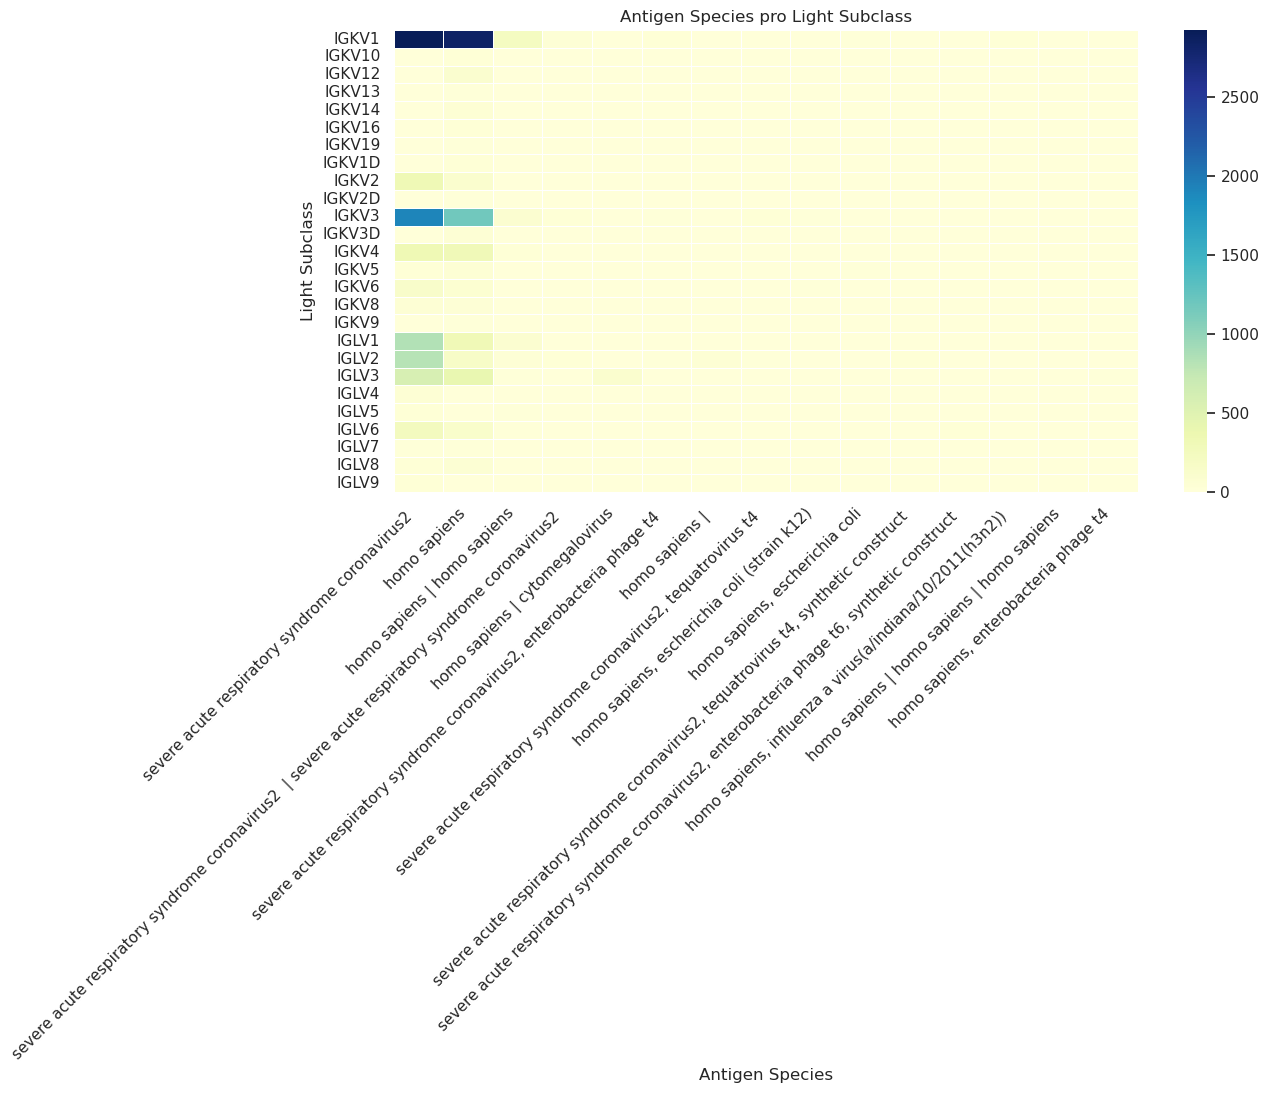

In [78]:
species_heatmap = (
    merged_total_Pfam_SMART_ProSiteProfiles.groupby(["light_subclass", "antigen_species"])
    .size()
    .unstack(fill_value=0)
)

# Optional nur die häufigsten Spezies anzeigen
top_species = species_heatmap.sum().sort_values(ascending=False).head(15).index
filtered = species_heatmap[top_species]

plt.figure(figsize=(12, 6))
sns.heatmap(filtered, cmap="YlGnBu", linewidths=0.5)
plt.title("Antigen Species pro Light Subclass")
plt.xlabel("Antigen Species")
plt.ylabel("Light Subclass")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


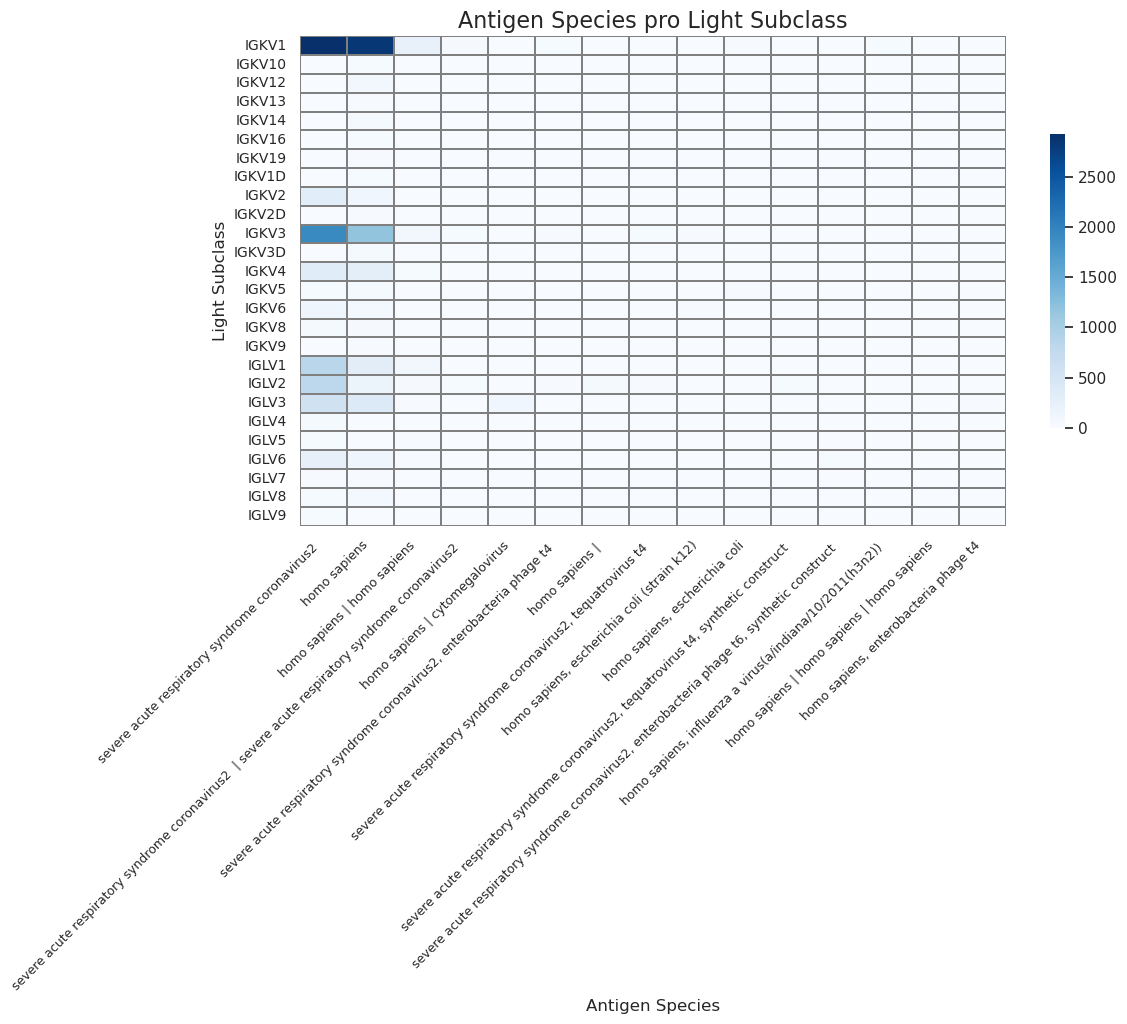

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Erstelle Heatmap mit klarerem Layout
plt.figure(figsize=(max(12, len(filtered.columns) * 0.6), max(6, len(filtered.index) * 0.4)))
ax = sns.heatmap(
    filtered,
    cmap="Blues",
    linewidths=0.3,
    linecolor="gray",
    square=False,
    cbar_kws={"shrink": 0.6},
)

# Achsentitel und Beschriftung
ax.set_title("Antigen Species pro Light Subclass", fontsize=16)
ax.set_xlabel("Antigen Species", fontsize=12)
ax.set_ylabel("Light Subclass", fontsize=12)

# Achsenticks anpassen
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

plt.tight_layout()
plt.show()


## 2. Focused light chain analysis (**relevant for poster**)

### 2.1 Approach of focused light chain analysis

What is the approach?  
Creating a data frame with InterProScan for domain information (lchains_1_ipr.tsv) and a data frame with gene family and antigen information (master_df_1_light_antigen_category).

"master_df_1_light_antigen_category.csv" is created with the previously prepared file "../data/lchain_sequences_deduplicated.fasta" including the light chain sequences and PDB-, Enitity- and Chain-ID information.


(2.2)

"lchains_1_ipr.tsv" is created with the "lchains_1_for_ipr.fasta" via the function "run_interproscan_fast". (2.3)

...

...



### 2.2 Create gene family and antigen data frame

(a) Separating PDB-, Enitity- and Chain-ID information in a data frame ("../results/master_df_1_light.csv") from the fasta ("../data/lchain_sequences_deduplicated.fasta")

In [15]:
# For package import and input and output files/directories 
from pathlib import Path
import pandas as pd

fasta_file = "../data/lchain_sequences_deduplicated.fasta"
output_file = "../results/master_df_1_light.csv"

output_dir = "../results"
interproscan_dir = "../interproscan-5.74-105.0"

In [ ]:
# Resulting df includs PDB_ID, Entity_ID, Chain_ID, FASTA_ID, Seq
import os
import pandas as pd

def parse_fasta(path):
    records, entry = [], {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if line.startswith(">"):
                if entry: records.append(entry)
                entry = {"ID": line[1:], "Seq": ""}
            else:
                entry["Seq"] += line.upper()
        if entry: records.append(entry)
    return records

def explode_headers(records):
    exploded = []
    for r in records:
        hdr, seq = r["ID"], r["Seq"]
        try:
            pdb = hdr[:4].upper()
            parts = hdr.split("_")
            entity = next((p.replace("entity", "") for p in parts if p.startswith("entity")), "")
            chains = next((p.replace("chain", "").split(",") for p in parts if p.startswith("chain")), [])
            for c in chains:
                exploded.append({
                    "PDB_ID": pdb, "Entity_ID": entity, "Chain_ID": c,
                    "FASTA_ID": hdr, "Seq": seq
                })
        except Exception as e:
            print(f"Fehler beim Header: {hdr} — {e}")
    return pd.DataFrame(exploded)

def main():
    if not os.path.isfile(fasta_file):
        print(f"FASTA fehlt: {fasta_file}")
        return

    output_dir = os.path.dirname(output_file)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    print("FASTA lesen...")
    df = explode_headers(parse_fasta(fasta_file))
    df.to_csv(output_file, index=False)
    print("Fertig:", output_file)

if __name__ == "__main__":
    main()


FASTA lesen...
Fertig: ../results/master_df_1_light.csv


(b) Cleaning the data frame "../data/light_subclass.csv" that strictly only "homo sapiens" or "severe acute respiratory syndrome coronavirus2" antigen_species remain and added this to the master data frame data frame which also includes gene family and anitgen information ("../results/master_df_1_light.csv") -> "../results/master_df_1_light_antigen.csv" 

In [ ]:
# Cleaned data frame is light_subclass_filtered_exact 
import pandas as pd

# Eingabe-/Ausgabepfade
input_file = "../data/light_subclass.csv"
output_file = "../results/light_subclass_filtered_exact.csv"

# Einlesen
df = pd.read_csv(input_file)

# Kleinbuchstaben, Whitespace säubern
df["antigen_species"] = df["antigen_species"].str.lower().str.strip()

# Nur exakt diese beiden Einträge erlauben
allowed = [
    "homo sapiens",
    "severe acute respiratory syndrome coronavirus2"
]

# Nur exakte Übereinstimmungen (kein contains!)
df_filtered = df[df["antigen_species"].isin(allowed)].copy()

# Optional: Duplikate pro PDB entfernen
df_filtered = df_filtered.drop_duplicates(subset="pdb")

# Speichern
df_filtered.to_csv(output_file, index=False)
print(f"✅ Nur reine human- oder SARS-CoV-2-Einträge gespeichert unter: {output_file}")




✅ Nur reine human- oder SARS-CoV-2-Einträge gespeichert unter: ../results/light_subclass_filtered_exact.csv


In [ ]:
# Add antigen species and light subclass and remove non homo sapiens and SARS-Cov2 species
import pandas as pd

# === Dateien einlesen ===
# Passe die Pfade ggf. an
master_df_path = "../results/master_df_1_light.csv"
filtered_df_path = "../results/light_subclass_filtered_exact.csv"

master_df = pd.read_csv(master_df_path)
filtered_df = pd.read_csv(filtered_df_path)

# === PDB IDs vereinheitlichen (Großbuchstaben) ===
master_df["PDB_ID"] = master_df["PDB_ID"].str.upper()
filtered_df["pdb"] = filtered_df["pdb"].str.upper()

# === Inner Join auf PDB ID ===
merged_df = pd.merge(
    master_df,
    filtered_df,
    left_on="PDB_ID",
    right_on="pdb",
    how="inner"
)

# === Überflüssige Spalte entfernen ===
merged_df.drop(columns=["pdb"], inplace=True)

# === Ergebnis speichern ===
output_path = "../results/master_df_1_light_antigen.csv"
merged_df.to_csv(output_path, index=False)

print(f"Merge abgeschlossen. Datei gespeichert unter: {output_path}")


Merge abgeschlossen. Datei gespeichert unter: ../results/master_df_1_light_antigen.csv


(c) Adding more detailed anitgen information with API 

In [30]:
# Add more detailed antigen categories with typo correction
import pandas as pd
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

# Datei laden
df = pd.read_csv("../results/master_df_1_light_antigen.csv")

# === Funktion zur Korrektur typischer Tippfehler ===
def clean_description(text):
    if not isinstance(text, str):
        return text
    corrections = {
        "chian": "chain",
        "anitbody": "antibody",
        "fragemnt": "fragment",
        "protin": "protein",
        "fab fragment": "fab fragment",  # falls z. B. „fragmnet“ ergänzt werden soll
    }
    for wrong, right in corrections.items():
        text = text.replace(wrong, right)
    return text

# === Funktion zur PDB-Abfrage inkl. Korrektur ===
def get_antigen_name(pdb_id):
    url = f"https://data.rcsb.org/rest/v1/core/entry/{pdb_id.lower()}"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            data = r.json()
            entities = data.get("rcsb_entry_container_identifiers", {}).get("polymer_entity_ids", [])
            if not entities:
                return None
            antigen_names = []
            for entity_id in entities:
                ent_url = f"https://data.rcsb.org/rest/v1/core/polymer_entity/{pdb_id.lower()}/{entity_id}"
                ent_r = requests.get(ent_url, timeout=10)
                if ent_r.status_code == 200:
                    ent_data = ent_r.json()
                    description = ent_data.get("rcsb_polymer_entity", {}).get("pdbx_description", "")
                    cleaned_description = clean_description(description.lower())
                    antigen_names.append(cleaned_description)
            return "; ".join(antigen_names)
        else:
            return None
    except:
        return None

# Nur einzigartige PDB-IDs abfragen
unique_pdb_ids = df["PDB_ID"].dropna().unique()

# Ergebnisse zwischenspeichern
antigen_name_map = {}

# Parallelisierte Abfrage
with ThreadPoolExecutor(max_workers=20) as executor:
    future_to_pdb = {executor.submit(get_antigen_name, pdb): pdb for pdb in unique_pdb_ids}
    for future in as_completed(future_to_pdb):
        pdb_id = future_to_pdb[future]
        try:
            antigen_name_map[pdb_id] = future.result()
        except Exception as e:
            antigen_name_map[pdb_id] = None

# Ergebnis zuordnen
df["antigen_name"] = df["PDB_ID"].map(antigen_name_map)

# === Antigen-Kategorien definieren ===
def categorize_antigen(name):
    if not isinstance(name, str):
        return "unknown"
    
    name = name.lower()

    # Viral
    if any(x in name for x in ["spike", "coronavirus", "virus", "influenza", "hiv", "sars", "cov"]):
        return "viral protein"

    # Cytokine
    elif any(x in name for x in ["il-", "interleukin", "tnf", "ifn", "gm-csf", "tgf"]):
        return "cytokine"

    # Immune marker / Checkpoints
    elif any(x in name for x in ["cd", "pd", "ctla", "lag", "tim", "btla"]):
        return "immune marker"

    # Tumor antigens
    elif any(x in name for x in ["her2", "egfr", "psma", "muc1", "cea", "mesothelin", "tyrosinase"]):
        return "tumor antigen"

    # Autoantigens
    elif any(x in name for x in ["hla", "dsdna", "ro", "la", "ana", "autoantigen", "sm", "jo-1"]):
        return "autoantigen"

    # Antibody fragments
    elif any(x in name for x in ["fab", "scfv", "f(ab)", "antibody", "fc"]):
        return "antibody fragment"

    else:
        return "other"

# Kategorie zuweisen
df["antigen_category"] = df["antigen_name"].apply(categorize_antigen)

# Ergebnis speichern
df.to_csv("../results/master_df_1_light_antigen_category.csv", index=False)
print("Verarbeitung abgeschlossen. Datei gespeichert.")


Verarbeitung abgeschlossen. Datei gespeichert.


### 2.3 Create domain information data frame

(a) Create "../results/lchains_1_for_ipr.fasta" a fasta for interproscan
/"../data/lchain_sequences_deduplicated.fasta" would have also worked

In [17]:
# Create "../results/lchains_1_for_ipr.fasta" for interproscan 
import pandas as pd
from pathlib import Path

# === Eingabe: CSV mit Sequenzen ===
input_csv = "../results/master_df_1_light.csv"
output_fasta = "../results/lchains_1_for_ipr.fasta"

df = pd.read_csv(input_csv)

# Erzeuge FASTA-Datei (eine Zeile pro Sequence)
with open(output_fasta, "w") as f:
    for _, row in df.iterrows():
        header = f">{row['PDB_ID']}_{row['Chain_ID']}"
        seq = row["Seq"]
        f.write(f"{header}\n{seq}\n")

print(f"Save FASTA: {output_fasta}")


Save FASTA: ../results/lchains_1_for_ipr.fasta


(b) Function for InterProScan which was optimized in the experimenting phase. Creates "../results/lchains_1_ipr.tsv" with important start and end information of domains in the analysed sequences.

In [19]:
# (Relevant function) Function for FAST InterProScan
import os
import subprocess
import multiprocessing

def run_interproscan_fast(interproscan_dir, input_fasta_path, output_path, temp_dir="../temp", applications="Pfam", extra_args=None):
    """
    Führt InterProScan mit konfigurierter Anwendung aus.

    Args:
        interproscan_dir (str): Pfad zum InterProScan-Installationsverzeichnis.
        input_fasta_path (str): Pfad zur Eingabe-FASTA-Datei.
        output_path (str): Zielpfad für die TSV-Ausgabe.
        temp_dir (str): Verzeichnis für temporäre Dateien (Default: "../temp").
        applications (str): Datenbanken für Analyse, z.B. "Pfam" oder "Pfam,SMART,ProSiteProfiles".
        extra_args (list): Zusätzliche Argumente als Liste (optional).

    Returns:
        result (subprocess.CompletedProcess): Ergebnisobjekt von subprocess.run
    """
    cpu_count = max(1, multiprocessing.cpu_count() - 2)
    print(f"Nutze {cpu_count} CPUs für InterProScan")

    cmd = [
        os.path.join(interproscan_dir, "interproscan.sh"),
        "-i", input_fasta_path,
        "-f", "tsv",
        "-goterms",
        "-iprlookup",
        "--applications", applications,
        "--tempdir", temp_dir,
        "-cpu", str(cpu_count),
        "-o", output_path
    ]

    if extra_args:
        cmd.extend(extra_args)

    result = subprocess.run(cmd, capture_output=True, text=True)

    print("Return code:", result.returncode)
    print("stdout:\n", result.stdout)
    print("stderr:\n", result.stderr)

    return result

In [21]:
# Run interproscan FAST to create "../results/lchains_1_ipr.tsv" with the needed domain information
run_interproscan_fast(
    interproscan_dir="../interproscan-5.74-105.0",
    input_fasta_path="../results/lchains_1_for_ipr.fasta",
    output_path="../results/lchains_1_ipr.tsv",
    temp_dir="../temp",
    applications="Pfam,SMART,ProSiteProfiles"
)


Nutze 14 CPUs für InterProScan
Return code: 0
stdout:
 04/07/2025 13:50:42:757 Welcome to InterProScan-5.74-105.0
04/07/2025 13:50:42:758 Running InterProScan v5 in STANDALONE mode... on Linux
04/07/2025 13:50:48:764 RunID: TomsBOOK2_20250704_135048631_5ks8
04/07/2025 13:50:57:762 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../results/lchains_1_for_ipr.fasta
04/07/2025 13:50:57:763 Running the following analyses:
[Pfam-37.3,ProSiteProfiles-2025_01,SMART-9.0]
Available matches will be retrieved from the pre-calculated match lookup service.

Matches for any sequences that are not represented in the lookup service will be calculated locally.
2025-07-04 13:51:00,192 [Thread-7] [uk.ac.ebi.interpro.scan.business.sequence.BerkeleyPrecalculatedProteinLookup:748] WARN - 

The version of InterProScan you are using is 5.74-105.0
The version of the lookup service you are using is 5.75-106.0
As the data in these versions is not the sam

CompletedProcess(args=['../interproscan-5.74-105.0/interproscan.sh', '-i', '../results/lchains_1_for_ipr.fasta', '-f', 'tsv', '-goterms', '-iprlookup', '--applications', 'Pfam,SMART,ProSiteProfiles', '--tempdir', '../temp', '-cpu', '14', '-o', '../results/lchains_1_ipr.tsv'], returncode=0, stdout='04/07/2025 13:50:42:757 Welcome to InterProScan-5.74-105.0\n04/07/2025 13:50:42:758 Running InterProScan v5 in STANDALONE mode... on Linux\n04/07/2025 13:50:48:764 RunID: TomsBOOK2_20250704_135048631_5ks8\n04/07/2025 13:50:57:762 Loading file /home/tomstraube/CODING/Data_Analysis_LINUX_NEW/group04-team03/blasting/domain_analysis/script/../results/lchains_1_for_ipr.fasta\n04/07/2025 13:50:57:763 Running the following analyses:\n[Pfam-37.3,ProSiteProfiles-2025_01,SMART-9.0]\nAvailable matches will be retrieved from the pre-calculated match lookup service.\n\nMatches for any sequences that are not represented in the lookup service will be calculated locally.\n2025-07-04 13:51:00,192 [Thread-7] [

### 2.4 Desciptive analysis of the created master data frame

(a) Goal: Understanding distribution within the dataset




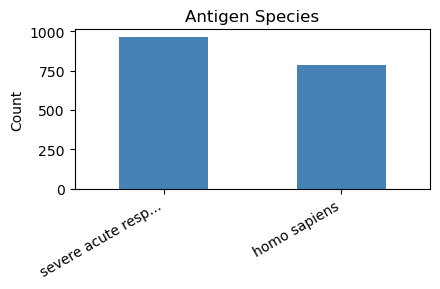

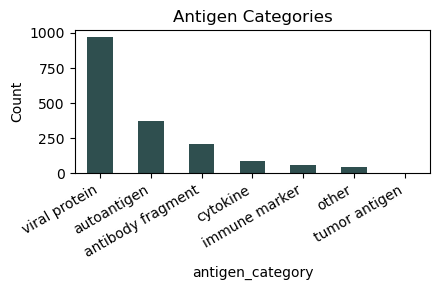

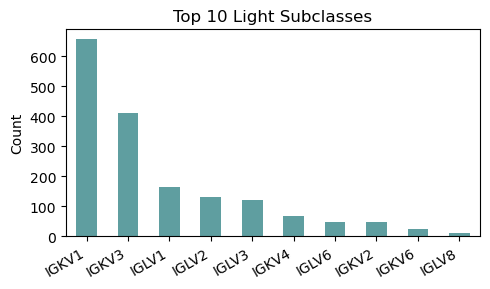

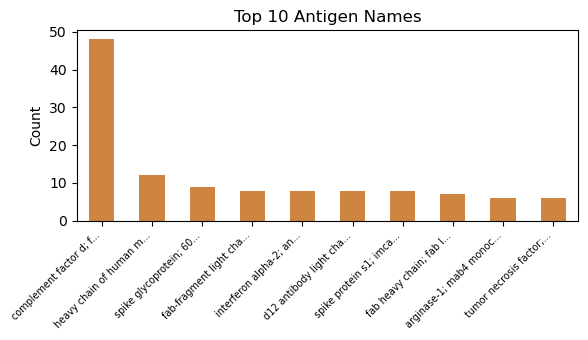

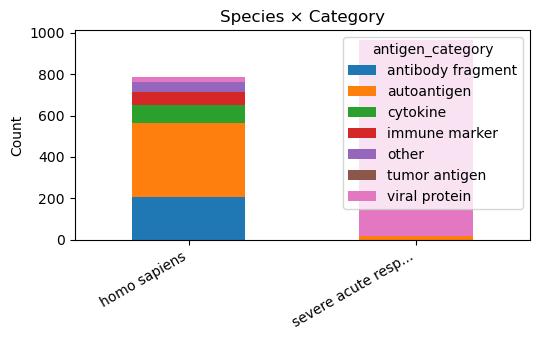

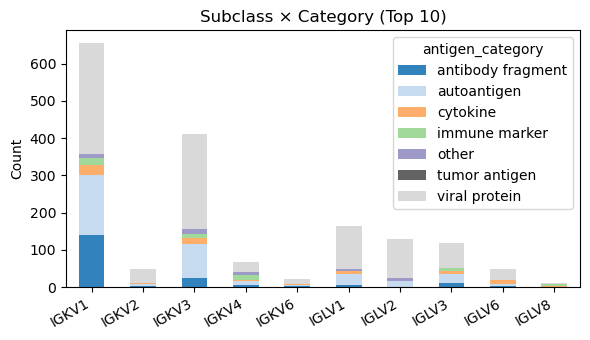

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# === Daten einlesen ===
df = pd.read_csv("../results/master_df_1_light_antigen_category.csv")

# === Hilfsfunktionen für gekürzte Labels ===
def shorten(text, length=20):
    if isinstance(text, str) and len(text) > length:
        return text[:length-3] + "..."
    return text

# === Pivot-Tabellen vorbereiten ===
pivot_species_cat = df.pivot_table(index="antigen_species", columns="antigen_category", aggfunc="size", fill_value=0)
top_subclasses = df["light_subclass"].value_counts().head(10).index
df_top = df[df["light_subclass"].isin(top_subclasses)]
pivot_subclass_cat = df_top.pivot_table(index="light_subclass", columns="antigen_category", aggfunc="size", fill_value=0)

# === 1. Antigen Species Distribution ===
plt.figure(figsize=(4.5, 3))
species_counts = df["antigen_species"].value_counts()
species_counts.index = [shorten(x) for x in species_counts.index]
species_counts.plot(kind="bar", color="steelblue")
plt.title("Antigen Species")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# === 2. Antigen Categories ===
plt.figure(figsize=(4.5, 3))
df["antigen_category"].value_counts().plot(kind="bar", color="darkslategray")
plt.title("Antigen Categories")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# === 3. Top 10 Light Subclasses ===
plt.figure(figsize=(5, 3))
light_counts = df["light_subclass"].value_counts().head(10)
light_counts.index = [shorten(x) for x in light_counts.index]
light_counts.plot(kind="bar", color="cadetblue")
plt.title("Top 10 Light Subclasses")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# === 4. Top 10 Antigen Names ===
plt.figure(figsize=(6, 3.5))
antigen_counts = df["antigen_name"].value_counts().head(10)
antigen_counts.index = [shorten(x, 25) for x in antigen_counts.index]
antigen_counts.plot(kind="bar", color="peru")
plt.title("Top 10 Antigen Names")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

# === 5. Species × Antigen Category ===
plt.figure(figsize=(5.5, 3.5))
pivot = pivot_species_cat.copy()
pivot.index = [shorten(x, 20) for x in pivot.index]
pivot.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Species × Category")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# === 6. Light Subclass × Antigen Category (Top 10) ===
plt.figure(figsize=(6, 3.5))
pivot = pivot_subclass_cat.copy()
pivot.index = [shorten(x, 15) for x in pivot.index]
pivot.plot(kind="bar", stacked=True, ax=plt.gca(), colormap="tab20c")
plt.title("Subclass × Category (Top 10)")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


Interpretation:  
-> homo sapiens and SARS-Cov2 are represented in similar proportion: good for comparison  
-> focus analysis on mainly represented gene families; For us interesting could be a comparision between IGLV1,2 and 3 and IGKV1,2 and 3  
-> CFD highly represented antigen; maybe further analysis if time 

### 2.5 Correlating genfamily and antigen species/category 

(a) Antigen species

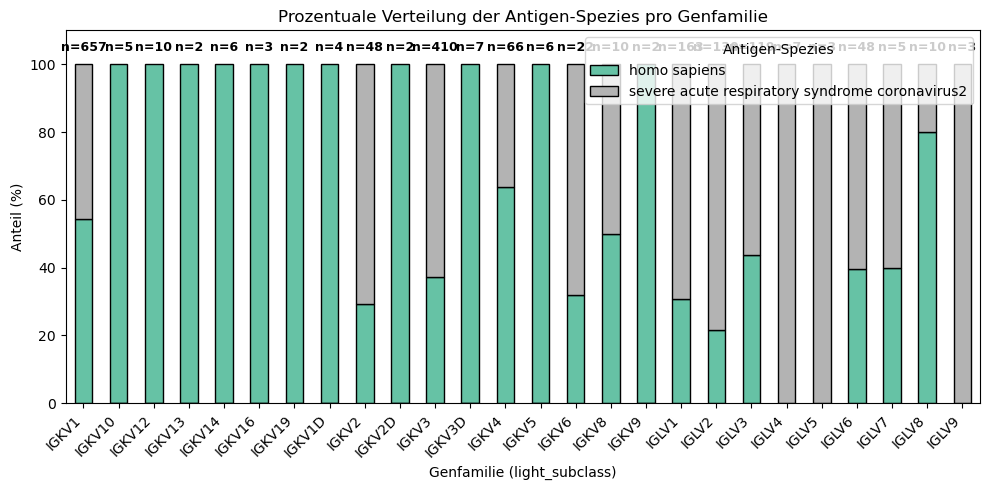

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# === Daten einlesen ===
df = pd.read_csv("../results/master_df_1_light_antigen_category.csv")

# === Häufigkeitstabelle: light_subclass × antigen_species ===
table = df.groupby(["light_subclass", "antigen_species"]).size().unstack(fill_value=0)

# === Gesamtanzahl pro Genfamilie (für Annotation) ===
total_counts = table.sum(axis=1)

# === Prozentuale Verteilung berechnen ===
percent_table = table.div(total_counts, axis=0) * 100

# === Plot vorbereiten ===
fig, ax = plt.subplots(figsize=(10, 5))
percent_table.plot(kind="bar", stacked=True, colormap="Set2", edgecolor="black", ax=ax)

# === Titel und Achsenbeschriftung ===
plt.title("Prozentuale Verteilung der Antigen-Spezies pro Genfamilie")
plt.xlabel("Genfamilie (light_subclass)")
plt.ylabel("Anteil (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Antigen-Spezies", loc="upper right")

# === Stichprobengröße (n=X) pro Balken anzeigen ===
for i, (label, total) in enumerate(total_counts.items()):
    ax.text(i, 103, f"n={total}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(0, 110)  # Platz für die Annotation oberhalb der Balken
plt.tight_layout()
plt.show()


-> Some gene families seem to be more assocciated with homo sapiens and SARS-Cov2 but sample sizes are for most gene families very small

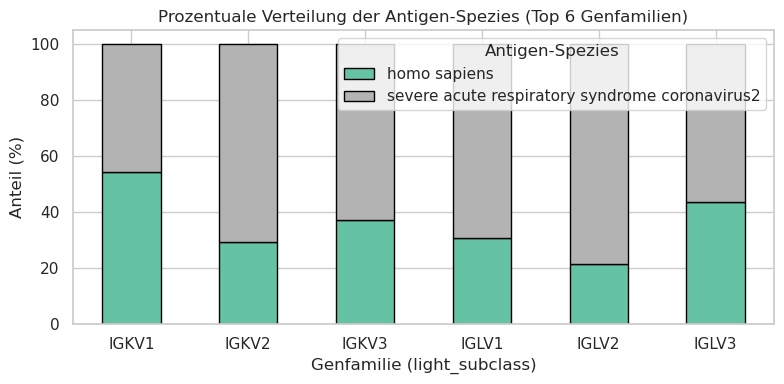

In [ ]:
# Plotting the often represented gene families
import pandas as pd
import matplotlib.pyplot as plt

# === CSV-Datei einlesen ===
df = pd.read_csv("../results/master_df_1_light_antigen_category.csv")

# === Nur gewünschte Genfamilien definieren ===
subset = ["IGKV1", "IGKV2", "IGKV3", "IGLV1", "IGLV2", "IGLV3"]

# === Filter auf subset und Top 6 nach Häufigkeit bestimmen ===
top6_subclasses = (
    df[df["light_subclass"].isin(subset)]
    ["light_subclass"]
    .value_counts()
    .head(6)
    .index
    .tolist()
)

# === DataFrame auf Top 6 Genfamilien beschränken ===
filtered_df = df[df["light_subclass"].isin(top6_subclasses)]

# === Häufigkeitstabelle: light_subclass × antigen_species ===
table = filtered_df.groupby(["light_subclass", "antigen_species"]).size().unstack(fill_value=0)

# === Prozentuale Verteilung berechnen ===
percent_table = table.div(table.sum(axis=1), axis=0) * 100

# === Plot erstellen ===
plt.figure(figsize=(8, 4))
percent_table.plot(
    kind="bar",
    stacked=True,
    colormap="Set2",
    edgecolor="black",
    ax=plt.gca()
)

plt.title("Prozentuale Verteilung der Antigen-Spezies (Top 6 Genfamilien)")
plt.xlabel("Genfamilie (light_subclass)")
plt.ylabel("Anteil (%)")
plt.xticks(rotation=0)
plt.legend(title="Antigen-Spezies", loc="upper right")
plt.tight_layout()
plt.show()


In [ ]:
IGKV1, IGKV3  -> about 50/50 homosapiens/SARS-Cov2
Others -> more SARS-Cov2 (interesting)

(b) Antigen category

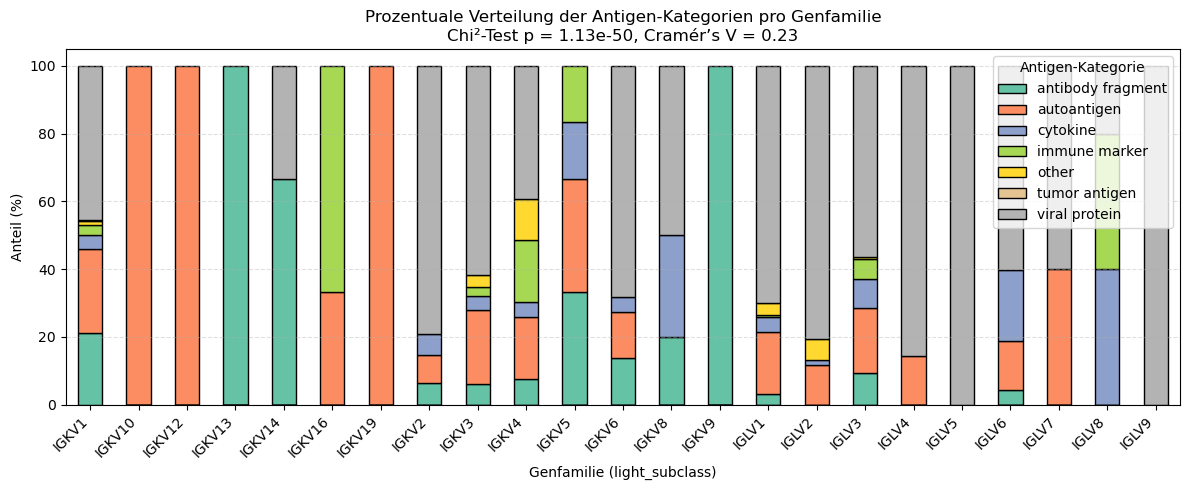

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# === CSV-Datei einlesen ===
df = pd.read_csv("../results/master_df_1_light_antigen_category.csv")

# === D-Gene entfernen (z. B. IGKV1D etc.)
df = df[~df["light_subclass"].str.contains("D", case=False, na=False)]

# === Kreuztabelle: light_subclass × antigen_category
table = df.groupby(["light_subclass", "antigen_category"]).size().unstack(fill_value=0)

# === Chi²-Test
chi2, p, dof, expected = chi2_contingency(table)
p_str = f"p = {p:.2e}"

# === Cramér's V
n = table.to_numpy().sum()
phi2 = chi2 / n
r, k = table.shape
cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))
v_str = f"Cramér’s V = {cramers_v:.2f}"

# === Prozentuale Verteilung innerhalb jeder Genfamilie berechnen ===
percent_table = table.div(table.sum(axis=1), axis=0) * 100

# === Plot ===
plt.figure(figsize=(12, 5))
percent_table.plot(
    kind="bar",
    stacked=True,
    colormap="Set2",
    edgecolor="black",
    ax=plt.gca()
)

plt.title(f"Prozentuale Verteilung der Antigen-Kategorien pro Genfamilie\nChi²-Test {p_str}, {v_str}", fontsize=12)
plt.xlabel("Genfamilie (light_subclass)")
plt.ylabel("Anteil (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Antigen-Kategorie", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


H0 hypotheses discarded by Chi^2-Test -> Gene families are not statistical independent from antigen catogories

Cramer's V-> moderate effect but what are the effects (further anlysis nesessary)

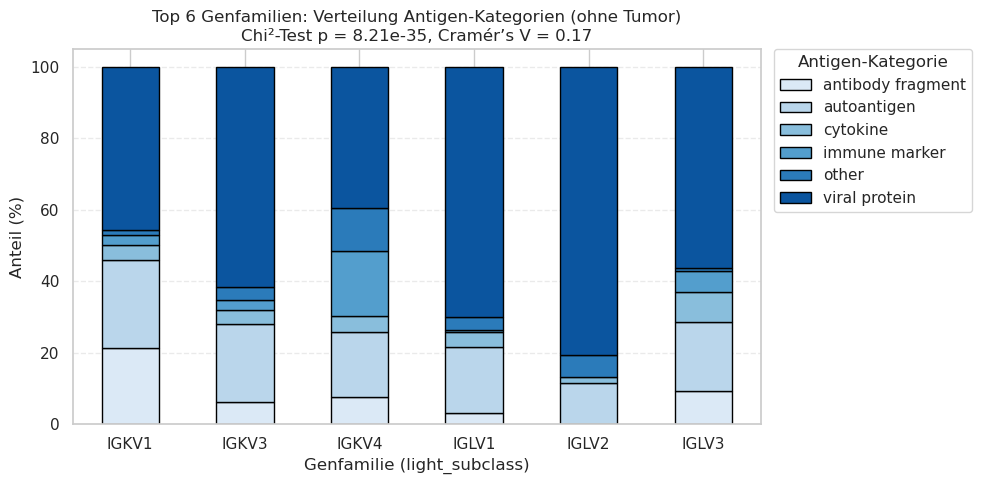

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# === Datei laden ===
df = pd.read_csv("../results/master_df_1_light_antigen_category.csv")

# === D-Gene ausschließen
df = df[~df["light_subclass"].str.contains("D", case=False, na=False)]

# === "tumor antigen" ausschließen
df = df[df["antigen_category"] != "tumor antigen"]

# === Top 6 häufigste light_subclass bestimmen
top6_subclasses = df["light_subclass"].value_counts().head(6).index.tolist()
df_top6 = df[df["light_subclass"].isin(top6_subclasses)]

# === Kreuztabelle: light_subclass × antigen_category
table = df_top6.groupby(["light_subclass", "antigen_category"]).size().unstack(fill_value=0)

# === Chi²-Test
chi2, p, dof, expected = chi2_contingency(table)
p_str = f"p = {p:.2e}"

# === Cramér’s V
n = table.to_numpy().sum()
phi2 = chi2 / n
r, k = table.shape
cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))
v_str = f"Cramér’s V = {cramers_v:.2f}"

# === Prozentuale Verteilung berechnen
percent_table = table.div(table.sum(axis=1), axis=0) * 100

# === Farbskala mit einem Farbton (z. B. "Blues")
cmap = plt.get_cmap("Blues")
colors = [cmap(i / (percent_table.shape[1] + 1)) for i in range(1, percent_table.shape[1] + 1)]

# === Plot erstellen
fig, ax = plt.subplots(figsize=(10, 5))
percent_table.plot(
    kind="bar",
    stacked=True,
    color=colors,
    edgecolor="black",
    ax=ax
)

# === Titel, Achsen, Stil
ax.set_title(f"Top 6 Genfamilien: Verteilung Antigen-Kategorien (ohne Tumor)\nChi²-Test {p_str}, {v_str}", fontsize=12)
ax.set_xlabel("Genfamilie (light_subclass)")
ax.set_ylabel("Anteil (%)")
ax.set_xticks(range(len(percent_table.index)))
ax.set_xticklabels(percent_table.index, rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# === Legende außerhalb
ax.legend(
    title="Antigen-Kategorie",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()


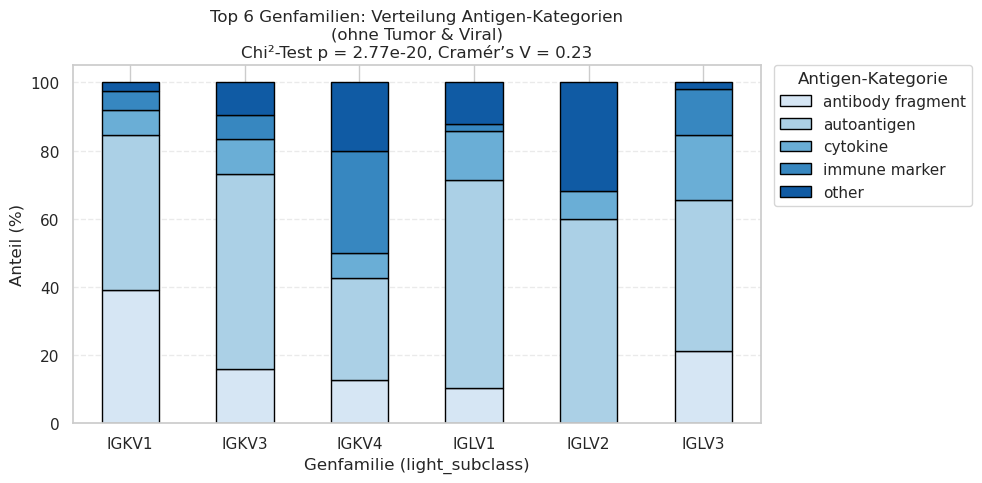

In [53]:
# Excluding tumor and viral antigens
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# === Datei laden ===
df = pd.read_csv("../results/master_df_1_light_antigen_category.csv")

# === D-Gene ausschließen
df = df[~df["light_subclass"].str.contains("D", case=False, na=False)]

# === "tumor antigen" und "viral protein" ausschließen
df = df[~df["antigen_category"].isin(["tumor antigen", "viral protein"])]

# === Top 6 häufigste light_subclass bestimmen
top6_subclasses = df["light_subclass"].value_counts().head(6).index.tolist()
df_top6 = df[df["light_subclass"].isin(top6_subclasses)]

# === Kreuztabelle: light_subclass × antigen_category
table = df_top6.groupby(["light_subclass", "antigen_category"]).size().unstack(fill_value=0)

# === Chi²-Test
chi2, p, dof, expected = chi2_contingency(table)
p_str = f"p = {p:.2e}"

# === Cramér’s V
n = table.to_numpy().sum()
phi2 = chi2 / n
r, k = table.shape
cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))
v_str = f"Cramér’s V = {cramers_v:.2f}"

# === Prozentuale Verteilung berechnen
percent_table = table.div(table.sum(axis=1), axis=0) * 100

# === Farbskala mit einem Farbton (z. B. "Blues")
cmap = plt.get_cmap("Blues")
colors = [cmap(i / (percent_table.shape[1] + 1)) for i in range(1, percent_table.shape[1] + 1)]

# === Plot erstellen
fig, ax = plt.subplots(figsize=(10, 5))
percent_table.plot(
    kind="bar",
    stacked=True,
    color=colors,
    edgecolor="black",
    ax=ax
)

# === Titel, Achsen, Stil
ax.set_title(f"Top 6 Genfamilien: Verteilung Antigen-Kategorien\n(ohne Tumor & Viral)\nChi²-Test {p_str}, {v_str}", fontsize=12)
ax.set_xlabel("Genfamilie (light_subclass)")
ax.set_ylabel("Anteil (%)")
ax.set_xticks(range(len(percent_table.index)))
ax.set_xticklabels(percent_table.index, rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# === Legende außerhalb platzieren
ax.legend(
    title="Antigen-Kategorie",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()


Similar to the plot with all gene families

### 2.6 gene family clustering based on kmer similarity via k-means and t-SNE (poster results -> (d))

(a) Extracting domain sequences based on InterProScan's domain sequence start and end information  

In [79]:
import pandas as pd

# === Daten einlesen ===
ipr_df = pd.read_csv("../results/lchains_1_ipr.tsv", sep="\t", header=None)
seq_df = pd.read_csv("../results/master_df_1_light_antigen_category.csv")

# === InterProScan vorbereiten ===
# [..] -> selecing via columns names
# [[..]] -> indexing via column position
ipr_df = ipr_df[[0, 6, 7, 11, 12]]  # Nur relevante Spalten
ipr_df.columns = ['protein_id', 'start', 'end', 'ipr_id', 'ipr_desc']

# Extrahiere PDB_ID und Chain_ID
ipr_df['PDB_ID'] = ipr_df['protein_id'].str.extract(r'^(\w{4})')
ipr_df['Chain_ID'] = ipr_df['protein_id'].str.extract(r'_(\w)$')

# === Merge via same columns PDB_ID and Chain_ID === 
# on=['PDB_ID', 'Chain_ID'] -> columns have to be identical
# how_'inner' -> logical 'and' 
merged = pd.merge(ipr_df, seq_df, on=['PDB_ID', 'Chain_ID'], how='inner')

# === Domain-Sequenz exakt extrahieren (start & end sind 1-basiert) ===
merged['domain_seq'] = merged.apply(
    lambda row: row['Seq'][int(row['start']) - 1 : int(row['end'])],
    axis=1
)

# === Ergebnis anzeigen ===
print(merged[['PDB_ID', 'Chain_ID', 'ipr_desc', 'start', 'end', 'domain_seq']].head())


  PDB_ID Chain_ID                       ipr_desc  start  end  \
0   6MI2        B    Immunoglobulin V-set domain     17   89   
1   6MI2        B  Immunoglobulin domain subtype      7  108   
2   6MI2        B  Immunoglobulin domain subtype    121  209   
3   6MI2        B          Immunoglobulin C1-set    131  205   
4   6MI2        B          Immunoglobulin C1-set    117  201   

                                          domain_seq  
0  TASITCSGDNIGDQYAHWYQQKPGQSPVLVIYQDKNRPSGIPERFS...  
1  PPSVSVSPGQTASITCSGDNIGDQYAHWYQQKPGQSPVLVIYQDKN...  
2  PPSSEELQANKATLVCLISDFYPGAVTVAWKADSSPVKAGVETTTP...  
3  KATLVCLISDFYPGAVTVAWKADSSPVKAGVETTTPSKQSNNKYAA...  
4  VTLFPPSSEELQANKATLVCLISDFYPGAVTVAWKADSSPVKAGVE...  


(b) Create frequency table with most frequent tri-, tetra- and pentapeptids (kmers: trimer, tetramer and pentamer) found in the domains

k -> length  
mer -> "polymer"

In [80]:
# 2.6(a) required
from collections import Counter

# === Funktion zur K-mer-Extraktion ===
# Iterating over sequence and give all overlapping k-mers out
# Example: ABCDE k=3 -> ["ABC","BCD","CDE"] (for the whole sequence)
def extract_kmers(sequence, k):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

# === Alle Domänensequenzen sammeln ===
# Create a list of all domain sequences
# And if NA not included
all_domain_seqs = merged['domain_seq'].dropna().tolist()

# === K-mer-Zählung für 3-, 4- und 5-mer ===
# counter for each kmer
kmer_counts = {k: Counter() for k in [3, 4, 5]}

# Iterating oder every domain sequence for definded lengths (k) and updating the count
for seq in all_domain_seqs:
    for k in [3, 4, 5]:
        kmer_counts[k].update(extract_kmers(seq, k))


# === Top-N pro k-mer-Länge extrahieren ===
# create a df with the highes counted kmers
top_kmers_combined = pd.DataFrame()

for k in [3, 4, 5]:
    top_k = kmer_counts[k].most_common(20)  # Top 20 pro Länge
    df = pd.DataFrame(top_k, columns=['kmer', 'count'])
    df['length'] = k
    top_kmers_combined = pd.concat([top_kmers_combined, df], ignore_index=True)

# === Ergebnis anzeigen ===
print(top_kmers_combined)


     kmer  count  length
0     SGS  12233       3
1     GSG   9154       3
2     TLT   8829       3
3     SGT   8666       3
4     LSS   6973       3
5     SLS   6811       3
6     RFS   6765       3
7     FSG   6734       3
8     TIS   6669       3
9     TLS   6626       3
10    YYC   6555       3
11    ASV   6338       3
12    WYQ   6083       3
13    SSL   5990       3
14    YQQ   5919       3
15    ADY   5771       3
16    LQS   5432       3
17    FYP   5430       3
18    LTI   5377       3
19    KAD   5339       3
20   SGSG   8808       4
21   RFSG   6702       4
22   FSGS   6518       4
23   WYQQ   5919       4
24   LTIS   5002       4
25   LQSG   4896       4
26   YYCQ   4681       4
27   QKPG   4680       4
28   QQKP   4602       4
29   GSGS   4481       4
30   TLTI   4473       4
31   YQQK   4450       4
32   GSGT   4433       4
33   LLIY   4318       4
34   SSTL   4034       4
35   QDSK   4033       4
36   STLT   4032       4
37   TLTL   4012       4
38   ASVV   4009       4


Succesfully extracted the twenty most frequent kmers  
frequence is an indicator for a conserved motif
Problem: Frequent does not mean conserved! Especially in a specific location.

(c) Non-linear approch: t-distributed Stochastic Neighbor Embedding (t-SNE) focused on most frequent gene families to identify cluster/groups

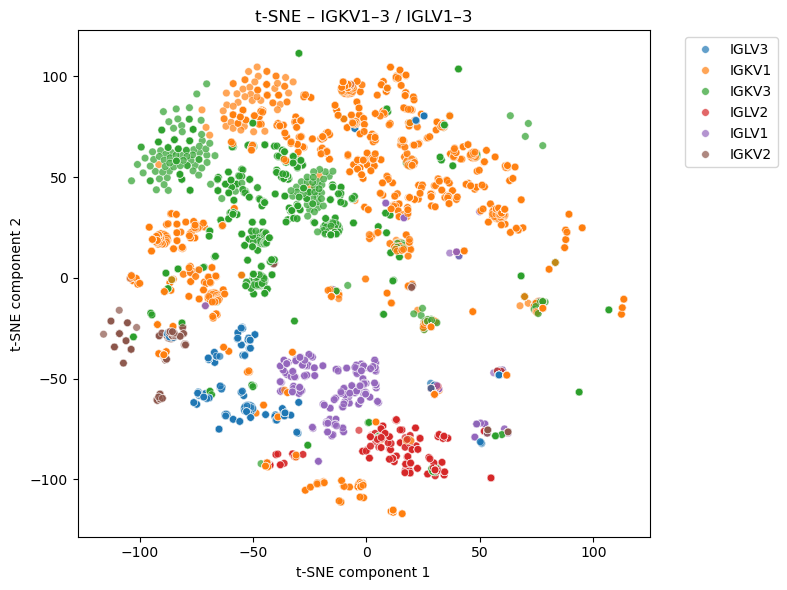

In [ ]:
# 2.6(a) required -> data loading
# 2.6(b) required -> kmer profiling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# ============================
# 3. Filtering IGKV1–3, IGLV1–3
# ============================
relevant_families = ['IGKV1', 'IGKV2', 'IGKV3', 'IGLV1', 'IGLV2', 'IGLV3']
filtered = merged[merged['light_subclass'].isin(relevant_families)].copy()
X_filtered = feature_df.loc[filtered.index]

# ============================
# 4. Scaling & t-SNE
# ============================
# Proper scaling (Z-Transformation) -> x'= (x-µ)/σ
# µ mean of column
# σ standard deviation of column
# x' -> Mittelwert = 0 und Standardabweichung = 1 -> All kmer's comparable scaled (highly frequent kmers do not dominat the result/all equal) 
# fit -> calculates mean and sd
# transform -> scales according to scaler (Z-transformation)
# Creates a numeric matrix -> rows: domain seq. columns: kmer -> P(seq.; kmer) = frequency
scaler = StandardScaler()
X_filtered_scaled = scaler.fit_transform(X_filtered)

# Model for dimension reduction with all filtered kmers -> 2D
# n_components=2 -> 2D
# random_state=42 -> Important because random startpoint causing different results without reproduceability; t-SNE is not determinitic
# perplexity=30 -> changes size of the local neighborhood 
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30)

# Runs the t-SNE dimension reduction creating a 2D-Numpy-Array (n,2)
# Takes high dimensional kmer vector and projects it into 2D, in a nonlinar fashion 
X_tsne = tsne_model.fit_transform(X_filtered_scaled)

# Adding the columns to filtered -> saving 2D coordinats 
filtered["TSNE1"] = X_tsne[:, 0] # first column
filtered["TSNE2"] = X_tsne[:, 1] # second column

# ============================
# 5. Visualisation
# ============================
plt.figure(figsize=(8, 6))
sns.scatterplot(data=filtered, x="TSNE1", y="TSNE2", hue="light_subclass", s=30, alpha=0.7)
plt.title("t-SNE – IGKV1–3 / IGLV1–3")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Results: 
IGLV1 and IGLV2 for good seperating cluster -> further investigation  
IGKV1 and IGKV3 spread but also seperate (upper quadrants because of kappa family?)  
IGKV2 -> small spread cluster (more data needed or high diversity)   
IGLV3 -> left quadrant but also spread (hard interpretation)  

Conclusion:  
Focus on IGLV1 and IGLV2 but other gene families also promising
Kappa family is more about the x-axis  
Lambda family is more below the y-axis  

(d) Non-linear approch: t-distributed Stochastic Neighbor Embedding (t-SNE) focused on IGLV1 and IGLV2 -> form quite seperated clusters in 2.6(c)

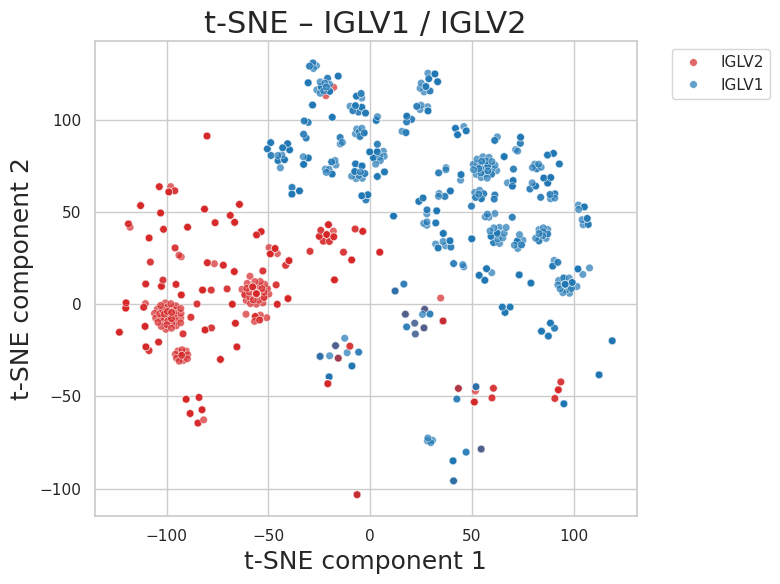

<Figure size 640x480 with 0 Axes>

In [112]:
# 2.6(a) required -> data loading
# 2.6(b) required -> kmer profiling
# 2.6(c) required -> pachage import
# ============================
# 3. Filtering IGLV1, IGLV2
# ============================
relevant_families = ['IGLV1', 'IGLV2']
filtered = merged[merged['light_subclass'].isin(relevant_families)].copy()
X_filtered = feature_df.loc[filtered.index]

# ============================
# 4. Scaling & t-SNE
# ============================
# Proper scaling (Z-Transformation) -> x'= (x-µ)/σ
# µ mean of column
# σ standard deviation of column
# x' -> Mittelwert = 0 und Standardabweichung = 1 -> All kmer's comparable scaled (highly frequent kmers do not dominat the result/all equal) 
# fit -> calculates mean and sd
# transform -> scales according to scaler (Z-transformation)
# Creates a numeric matrix -> rows: domain seq. columns: kmer -> P(seq.; kmer) = frequency
scaler = StandardScaler()
X_filtered_scaled = scaler.fit_transform(X_filtered)

# Model for dimension reduction with all filtered kmers -> 2D
# n_components=2 -> 2D
# random_state=42 -> Important because random startpoint causing different results without reproduceability; t-SNE is not determinitic
# perplexity=30 -> changes size of the local neighborhood 
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30)

# Runs the t-SNE dimension reduction creating a 2D-Numpy-Array (n,2)
# Takes high dimensional kmer vector and projects it into 2D, in a nonlinar fashion 
X_tsne = tsne_model.fit_transform(X_filtered_scaled)

# Adding the columns to filtered -> saving 2D coordinats 
filtered["TSNE1"] = X_tsne[:, 0] # first column
filtered["TSNE2"] = X_tsne[:, 1] # second column

# 5. Visualisation
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=filtered, 
    x="TSNE1", 
    y="TSNE2", 
    hue="light_subclass", 
    palette={"IGLV1": "#1f77b4", "IGLV2": "#d62728"}, 
    s=30, 
    alpha=0.7
)
plt.title("t-SNE – IGLV1 / IGLV2", fontsize=22)
plt.xlabel("t-SNE component 1", fontsize=18)
plt.ylabel("t-SNE component 2", fontsize=18)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


plt.savefig("../results/t-SNE_IGLV1_IGLV2.png", dpi=300)




t-SNE component 1 and 2 -> just for visualisation of similarities 

Results: IGLV2 and IGLV1 are well seperated -> systemic kmer different?
But still some "mixed" -> biological relevents? or wrong annotated sequences?
IGLV2 -> circle with very similar sequences
IGLV1 -> widly spread -> more diverse

Outlook: Similar analysis for other IGKV and IGLV


(f) Ploting t-SNE with antigen category and species

<Axes: xlabel='TSNE1', ylabel='TSNE2'>

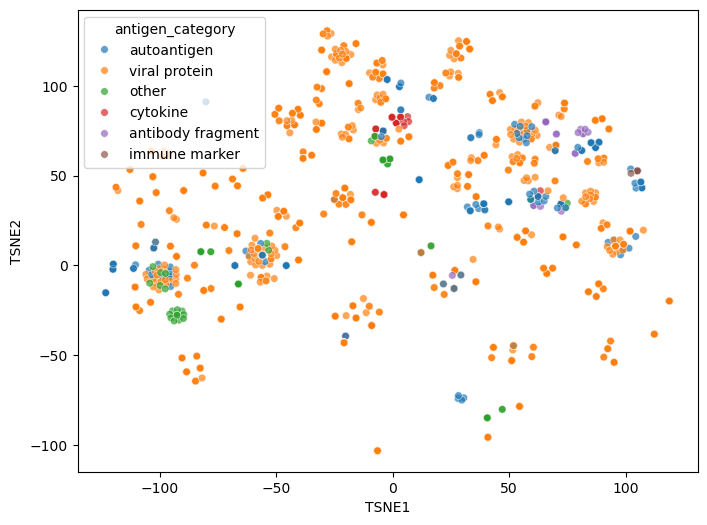

In [69]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=filtered,
    x="TSNE1",
    y="TSNE2",
    hue="antigen_category",   # << HIER NACH FUNKTION STATT SUBKLASSE
    s=30,
    alpha=0.7
)


<Axes: xlabel='TSNE1', ylabel='TSNE2'>

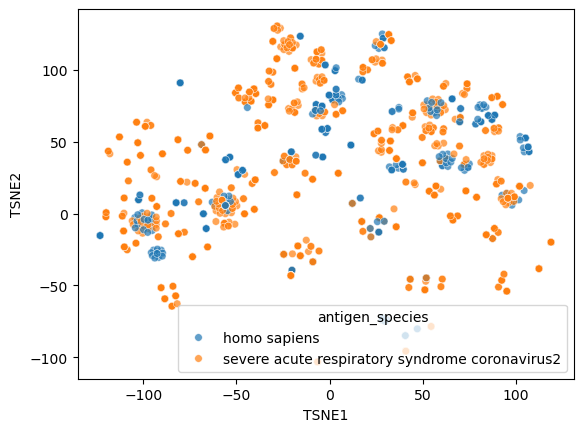

In [70]:
sns.scatterplot(
    data=filtered,
    x="TSNE1",
    y="TSNE2",
    hue="antigen_species",   # z. B. human, viral, mouse, etc.
    s=30,
    alpha=0.7
)


Conclusion: Domain sequences are not clearly sperated -> light chains are diverse and similar domains can bind different antigen species and categories

### 2.7 Relative position analysis of most significant kmer (Results of poster -> (c))

(a) Filtering and grouping IGLV1 and IGLV2

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import ttest_ind

# ============================
# 3. Filtering and grouping IGLV1 and IGLV2
# ============================
# merged has als sequence and annotation info 
# -> .isin filteres in 'light_subclass' only if 'IGLV1' OR 'IGLV2' is true
# feature_df of kerm counts per domain (row: domain column: kmer)
# subset.index -> are all row information filter for filtered domains
# feature_df.loc takes kmer-vectors from filtered domains
# adding gene family information for each domain (row) to the X_subset (kmer-count-matrix)
subset = merged[merged['light_subclass'].isin(['IGLV1', 'IGLV2'])].copy()
X_subset = feature_df.loc[subset.index]
X_subset['light_subclass'] = subset['light_subclass'].values

# Creating to groups for IGLV1 and IGLV2
group1 = X_subset[X_subset['light_subclass'] == 'IGLV1'].drop(columns='light_subclass')
group2 = X_subset[X_subset['light_subclass'] == 'IGLV2'].drop(columns='light_subclass')


(b) t-Test
Which kmer's are significantly different between the two group in there counts?

/tmp/ipykernel_1517126/2000903235.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_effects, x='-log10(p)', y='kmer', palette='viridis')


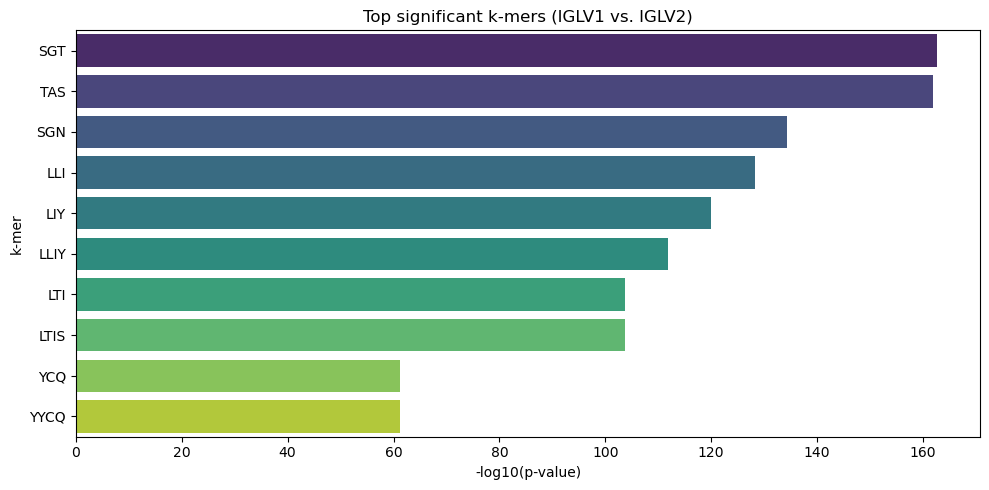

In [76]:
# Unpaired t-test for every column
# H0 (Null hypothesis) K-mer occurs equally frequently in IGLV1 and IGLV2
# H1 K-mer occurs with varying frequency in the groups
# equal_var=False -> Welch’s t-Test (safer for unequal groups)
# -> result is a List of [kmer, t-values, p-values]
ttest_results = []
for kmer in group1.columns:
    stat, pval = ttest_ind(group1[kmer], group2[kmer], equal_var=False)
    ttest_results.append((kmer, stat, pval))

# Creating a data frame from the list
# for better visualisation use log scale 
# sorting for most significant kmers ("statistically most different kmer count between the group")
ttest_df = pd.DataFrame(ttest_results, columns=['kmer', 't_statistic', 'p_value'])
ttest_df['-log10(p)'] = -np.log10(ttest_df['p_value'])
ttest_df = ttest_df.sort_values('p_value')

# Only keep significant and top 10 kmers
significant_kmers = ttest_df[ttest_df['p_value'] < 0.01]
top_effects = significant_kmers.sort_values('-log10(p)', ascending=False).head(10)

# Visualize top 10
plt.figure(figsize=(10, 5))
sns.barplot(data=top_effects, x='-log10(p)', y='kmer', palette='viridis')
plt.title('Top significant k-mers (IGLV1 vs. IGLV2)')
plt.xlabel('-log10(p-value)')
plt.ylabel('k-mer')
plt.tight_layout()
plt.show()

Conclusion: SGT trimer seems most promising with p-value of about 10^(-160)

(c) Position analysis for top k-mer

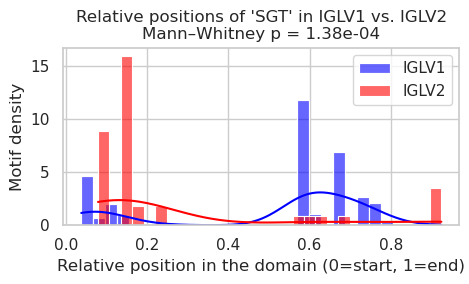

<Figure size 640x480 with 0 Axes>

In [113]:
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

kmer_of_interest = "SGT"

def find_relative_positions(sequence, kmer):
    positions = []
    for i in range(len(sequence) - len(kmer) + 1):
        if sequence[i:i+len(kmer)] == kmer:
            rel_pos = i / len(sequence)
            positions.append(rel_pos)
    return positions

positions_IGLV1 = []
positions_IGLV2 = []

for _, row in subset.iterrows():
    seq = row['domain_seq']
    rel_positions = find_relative_positions(seq, kmer_of_interest)
    if row['light_subclass'] == 'IGLV1':
        positions_IGLV1.extend(rel_positions)
    elif row['light_subclass'] == 'IGLV2':
        positions_IGLV2.extend(rel_positions)

# Mann-Whitney U-test: checks whether the distributions are systematically different
u_stat, p_val = mannwhitneyu(positions_IGLV1, positions_IGLV2, alternative='two-sided')

# Plot with p-value
plt.figure(figsize=(5, 3))
sns.histplot(positions_IGLV1, bins=30, color='blue', label='IGLV1', kde=True, stat="density", alpha=0.6)
sns.histplot(positions_IGLV2, bins=30, color='red', label='IGLV2', kde=True, stat="density", alpha=0.6)
plt.title(f"Relative positions of '{kmer_of_interest}' in IGLV1 vs. IGLV2\nMann–Whitney p = {p_val:.2e}")
plt.xlabel("Relative position in the domain (0=start, 1=end)")
plt.ylabel("Motif density")
plt.legend()
plt.tight_layout()
plt.show()

plt.savefig("../results/SGT_relative_positions.png", dpi=300)



Result:  
The K-mer SGT occurs at systematically different positions in IGLV1 and IGLV2 domains (Mann-Whitney U-test, p = 1.4×10^(-4)).
While it occurs predominantly N-terminal in IGLV2, it appears more central to C-terminal in IGLV1.  
Conclusion:  
This suggests a position-dependent structural or functional significance of SGT in different gene families.

## 3. OUTLOOK

Further investigate SGT kmer location (CDR1,CDR2 and CDR3?) and antigen binding  
Adding motif comparison of IGLV3 and IGKV1-3 (promising -> also cluster formation)  
Analyzing more kmer‘s for a broader picture  
AlphaFold modeling for specific antigens
Analyzing motifs in heavy chains -> (structurally important for theraputic antibody development?)  

Next step: Find CDR start and end location in PDB sequences  
Problem yet is SabDab has no CDRs information in the database
